# LOAD DATA
We will load all the data except 219 V columns that were determined redundant by correlation analysis

In [1]:
import sys
print(sys.executable)

/Users/hovietbach/miniforge3/envs/Financial_Fraud_Detection_Thesis/bin/python


In [2]:
import os
print(os.environ.get("CONDA_DEFAULT_ENV"))

Financial_Fraud_Detection_Thesis


In [3]:
BUILD95 = True
BUILD96 = True

import numpy as np, pandas as pd, os, gc
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train_transaction = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/ieee-fraud-detection/csv_imported_file/train_transaction.csv')

train_identity = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/ieee-fraud-detection/csv_imported_file/train_identity.csv')

test_transaction = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/ieee-fraud-detection/csv_imported_file/test_transaction.csv')

test_identity = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/ieee-fraud-detection/csv_imported_file/test_identity.csv')

In [5]:
train_transaction

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
train_transaction['addr2'].value_counts()

addr2
87.0    520481
60.0      3084
96.0       638
32.0        91
65.0        82
         ...  
82.0         1
89.0         1
94.0         1
55.0         1
93.0         1
Name: count, Length: 74, dtype: int64

In [7]:
print(max(train_transaction.TransactionDT)/(24*60*60)) # The last day in the train_transaction

182.99920138888888


In [8]:
train_identity

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144228,3577521,-15.0,145955.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 66.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,F3111 Build/33.3.A.1.97
144229,3577526,-5.0,172059.0,NaN,NaN,1.0,-5.0,NaN,NaN,NaN,...,chrome 55.0 for android,32.0,855x480,match_status:2,T,F,T,F,mobile,A574BL Build/NMF26F
144230,3577529,-20.0,632381.0,NaN,NaN,-1.0,-36.0,NaN,NaN,NaN,...,chrome 65.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,Moto E (4) Plus Build/NMA26.42-152
144231,3577531,-5.0,55528.0,0.0,0.0,0.0,-7.0,NaN,NaN,0.0,...,chrome 66.0,24.0,2560x1600,match_status:2,T,F,T,F,desktop,MacOS


In [9]:
string_cols_transaction = train_transaction.select_dtypes(include=["object", "string"]).columns.tolist()
print(string_cols_transaction)

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


In [10]:
string_cols_identity = train_identity.select_dtypes(include=["object", "string"]).columns.tolist()
print(string_cols_identity)

['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [11]:
string_cols_test_identity = [
    c for c in test_identity.select_dtypes(include=["object", "string"]).columns
    if c not in ["DeviceType", "DeviceInfo"]
]
print(string_cols_test_identity)

['id-12', 'id-15', 'id-16', 'id-23', 'id-27', 'id-28', 'id-29', 'id-30', 'id-31', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38']


In [12]:
str_type = string_cols_transaction + string_cols_identity + string_cols_test_identity
print(str_type)
print(len(str_type))

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'id-12', 'id-15', 'id-16', 'id-23', 'id-27', 'id-28', 'id-29', 'id-30', 'id-31', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38']
46


In [13]:
## FIRST 53 COLUMNS
cols = train_transaction.columns[
    ~train_transaction.columns.str.startswith("V") &
    (train_transaction.columns != "isFraud")
].tolist()
print(cols)

['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


In [14]:
# Number of V columns
v_cols = train_transaction.columns[
    train_transaction.columns.str.startswith("V")
].tolist()
print(len(v_cols))

339


In [15]:
# V COLUMNS TO LOAD DECIDED BY CORRELATION EDA
# https://www.kaggle.com/cdeotte/eda-for-columns-v-and-id

v =  [1, 3, 4, 6, 8, 11]
v += [13, 14, 17, 20, 23, 26, 27, 30]
v += [36, 37, 40, 41, 44, 47, 48]
v += [54, 56, 59, 62, 65, 67, 68, 70]
v += [76, 78, 80, 82, 86, 88, 89, 91]

#v += [96, 98, 99, 104] #relates to groups, no NAN
v += [107, 108, 111, 115, 117, 120, 121, 123] # maybe group, no NAN
v += [124, 127, 129, 130, 136] # relates to groups, no NAN

# LOTS OF NAN BELOW
v += [138, 139, 142, 147, 156, 162] #b1
v += [165, 160, 166] #b1
v += [178, 176, 173, 182] #b2
v += [187, 203, 205, 207, 215] #b2
v += [169, 171, 175, 180, 185, 188, 198, 210, 209] #b2
v += [218, 223, 224, 226, 228, 229, 235] #b3
v += [240, 258, 257, 253, 252, 260, 261] #b3
v += [264, 266, 267, 274, 277] #b3
v += [220, 221, 234, 238, 250, 271] #b3

v += [294, 284, 285, 286, 291, 297] # relates to groups, no NAN
v += [303, 305, 307, 309, 310, 320] # relates to groups, no NAN
v += [281, 283, 289, 296, 301, 314] # relates to groups, no NAN
#v += [332, 325, 335, 338] # b4 lots NAN

cols += ['V'+str(x) for x in v]
dtypes = {}
for c in cols+['id_0'+str(x) for x in range(1,10)]+['id_'+str(x) for x in range(10,34)]+\
    ['id-0'+str(x) for x in range(1,10)]+['id-'+str(x) for x in range(10,34)]:
        dtypes[c] = 'float32'
for c in str_type: dtypes[c] = 'category'

In [16]:
print("Number of kept V-columns: ", len(v))

Number of kept V-columns:  120


In [17]:
print('Number of eliminated V-columns: ', len(v_cols) - len(v))

Number of eliminated V-columns:  219


In [18]:
print(dtypes)

{'TransactionID': 'float32', 'TransactionDT': 'float32', 'TransactionAmt': 'float32', 'ProductCD': 'category', 'card1': 'float32', 'card2': 'float32', 'card3': 'float32', 'card4': 'category', 'card5': 'float32', 'card6': 'category', 'addr1': 'float32', 'addr2': 'float32', 'dist1': 'float32', 'dist2': 'float32', 'P_emaildomain': 'category', 'R_emaildomain': 'category', 'C1': 'float32', 'C2': 'float32', 'C3': 'float32', 'C4': 'float32', 'C5': 'float32', 'C6': 'float32', 'C7': 'float32', 'C8': 'float32', 'C9': 'float32', 'C10': 'float32', 'C11': 'float32', 'C12': 'float32', 'C13': 'float32', 'C14': 'float32', 'D1': 'float32', 'D2': 'float32', 'D3': 'float32', 'D4': 'float32', 'D5': 'float32', 'D6': 'float32', 'D7': 'float32', 'D8': 'float32', 'D9': 'float32', 'D10': 'float32', 'D11': 'float32', 'D12': 'float32', 'D13': 'float32', 'D14': 'float32', 'D15': 'float32', 'M1': 'category', 'M2': 'category', 'M3': 'category', 'M4': 'category', 'M5': 'category', 'M6': 'category', 'M7': 'category',

In [19]:
print(cols)

['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13', 'V14', 'V17', 'V20', 'V23', 'V26', 'V27', 'V30', 'V36', 'V37', 'V40', 'V41', 'V44', 'V47', 'V48', 'V54', 'V56', 'V59', 'V62', 'V65', 'V67', 'V68', 'V70', 'V76', 'V78', 'V80', 'V82', 'V86', 'V88', 'V89', 'V91', 'V107', 'V108', 'V111', 'V115', 'V117', 'V120', 'V121', 'V123', 'V124', 'V127', 'V129', 'V130', 'V136', 'V138', 'V139', 'V142', 'V147', 'V156', 'V162', 'V165', 'V160', 'V166', 'V178', 'V176', 'V173', 'V182', 'V187', 'V203', 'V205', 'V207', 'V215', 'V169', 'V171', 'V175', 'V180', 'V185', 'V188', 'V198', 'V210', 'V209

In [20]:
%%time
# LOAD TRAIN
X_train = pd.read_csv('//Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/ieee-fraud-detection/csv_imported_file/train_transaction.csv', index_col='TransactionID', dtype=dtypes, usecols=cols + ['isFraud'])

CPU times: user 4.05 s, sys: 442 ms, total: 4.5 s
Wall time: 19.4 s


In [21]:
train_transaction

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
X_train

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V296,V297,V301,V303,V305,V307,V309,V310,V314,V320
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000.0,0,86400.0,68.500000,W,13926.0,NaN,150.0,discover,142.0,credit,...,0.0,0.0,0.0,0.0,1.0,117.000000,0.0,0.000000,0.000000,0.000000
2987001.0,0,86401.0,29.000000,W,2755.0,404.0,150.0,mastercard,102.0,credit,...,0.0,0.0,0.0,0.0,1.0,0.000000,0.0,0.000000,0.000000,0.000000
2987002.0,0,86469.0,59.000000,W,4663.0,490.0,150.0,visa,166.0,debit,...,0.0,0.0,0.0,0.0,1.0,0.000000,0.0,0.000000,0.000000,0.000000
2987003.0,0,86499.0,50.000000,W,18132.0,567.0,150.0,mastercard,117.0,debit,...,0.0,0.0,0.0,0.0,1.0,1758.000000,0.0,354.000000,0.000000,0.000000
2987004.0,0,86506.0,50.000000,H,4497.0,514.0,150.0,mastercard,102.0,credit,...,0.0,0.0,0.0,1.0,1.0,0.000000,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3577535.0,0,15811047.0,49.000000,W,6550.0,NaN,150.0,visa,226.0,debit,...,0.0,0.0,0.0,0.0,1.0,47.950001,0.0,47.950001,47.950001,0.000000
3577536.0,0,15811049.0,39.500000,W,10444.0,225.0,150.0,mastercard,224.0,debit,...,0.0,0.0,0.0,0.0,1.0,0.000000,0.0,0.000000,0.000000,0.000000
3577537.0,0,15811079.0,30.950001,W,12037.0,595.0,150.0,mastercard,224.0,debit,...,0.0,0.0,0.0,0.0,1.0,0.000000,0.0,0.000000,0.000000,0.000000


In [23]:
train_id = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/ieee-fraud-detection/csv_imported_file/train_identity.csv', index_col='TransactionID', dtype=dtypes)

In [24]:
train_id

,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987004.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
2987008.0,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2987010.0,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
2987011.0,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
2987016.0,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3577521.0,-15.0,145955.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,chrome 66.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,F3111 Build/33.3.A.1.97
3577526.0,-5.0,172059.0,NaN,NaN,1.0,-5.0,NaN,NaN,NaN,NaN,...,chrome 55.0 for android,32.0,855x480,match_status:2,T,F,T,F,mobile,A574BL Build/NMF26F
3577529.0,-20.0,632381.0,NaN,NaN,-1.0,-36.0,NaN,NaN,NaN,NaN,...,chrome 65.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,Moto E (4) Plus Build/NMA26.42-152


In [25]:
print(train_transaction.dtypes.to_frame("dtype"))
print(train_identity.dtypes.to_frame("dtype"))

                  dtype
TransactionID     int64
isFraud           int64
TransactionDT     int64
TransactionAmt  float64
ProductCD           str
...                 ...
V335            float64
V336            float64
V337            float64
V338            float64
V339            float64

[394 rows x 1 columns]
                 dtype
TransactionID    int64
id_01          float64
id_02          float64
id_03          float64
id_04          float64
id_05          float64
id_06          float64
id_07          float64
id_08          float64
id_09          float64
id_10          float64
id_11          float64
id_12              str
id_13          float64
id_14          float64
id_15              str
id_16              str
id_17          float64
id_18          float64
id_19          float64
id_20          float64
id_21          float64
id_22          float64
id_23              str
id_24          float64
id_25          float64
id_26          float64
id_27              str
id_28              st

In [26]:
print(X_train.dtypes.to_frame("dtype"))
print(train_id.dtypes.to_frame("dtype"))

                   dtype
isFraud            int64
TransactionDT    float32
TransactionAmt   float32
ProductCD       category
card1            float32
...                  ...
V307             float32
V309             float32
V310             float32
V314             float32
V320             float32

[174 rows x 1 columns]
               dtype
id_01        float32
id_02        float32
id_03        float32
id_04        float32
id_05        float32
id_06        float32
id_07        float32
id_08        float32
id_09        float32
id_10        float32
id_11        float32
id_12       category
id_13        float32
id_14        float32
id_15       category
id_16       category
id_17        float32
id_18        float32
id_19        float32
id_20        float32
id_21        float32
id_22        float32
id_23       category
id_24        float32
id_25        float32
id_26        float32
id_27       category
id_28       category
id_29       category
id_30       category
id_31       category
id_3

In [27]:
X_train = X_train.merge(train_id, how='left', left_index=True, right_index=True)
print(X_train)
print(X_train.dtypes)

               isFraud  TransactionDT  TransactionAmt ProductCD    card1  \
TransactionID                                                              
2987000.0            0        86400.0       68.500000         W  13926.0   
2987001.0            0        86401.0       29.000000         W   2755.0   
2987002.0            0        86469.0       59.000000         W   4663.0   
2987003.0            0        86499.0       50.000000         W  18132.0   
2987004.0            0        86506.0       50.000000         H   4497.0   
...                ...            ...             ...       ...      ...   
3577535.0            0     15811047.0       49.000000         W   6550.0   
3577536.0            0     15811049.0       39.500000         W  10444.0   
3577537.0            0     15811079.0       30.950001         W  12037.0   
3577538.0            0     15811088.0      117.000000         W   7826.0   
3577539.0            0     15811131.0      279.950012         W  15066.0   

           

In [28]:
# LOAD TEST
X_test = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/ieee-fraud-detection/csv_imported_file/test_transaction.csv', index_col='TransactionID', dtype=dtypes, usecols=cols)
test_id = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/ieee-fraud-detection/csv_imported_file/test_identity.csv', index_col='TransactionID', dtype=dtypes)
fix = {o:n for o, n in zip(test_id.columns, train_id.columns)}
print(fix)
# print("test_id before renaming: ", test_id)
test_id.rename(columns=fix, inplace=True)
X_test = X_test.merge(test_id, how='left', left_index=True, right_index=True)
# TARGET
y_train = X_train['isFraud'].copy()
# del train_id, test_id, X_train['isFraud']; x = gc.collect()
del X_train['isFraud']; x = gc.collect()
# PRINT STATUS
print('Train shape',X_train.shape,'test shape',X_test.shape)

{'id-01': 'id_01', 'id-02': 'id_02', 'id-03': 'id_03', 'id-04': 'id_04', 'id-05': 'id_05', 'id-06': 'id_06', 'id-07': 'id_07', 'id-08': 'id_08', 'id-09': 'id_09', 'id-10': 'id_10', 'id-11': 'id_11', 'id-12': 'id_12', 'id-13': 'id_13', 'id-14': 'id_14', 'id-15': 'id_15', 'id-16': 'id_16', 'id-17': 'id_17', 'id-18': 'id_18', 'id-19': 'id_19', 'id-20': 'id_20', 'id-21': 'id_21', 'id-22': 'id_22', 'id-23': 'id_23', 'id-24': 'id_24', 'id-25': 'id_25', 'id-26': 'id_26', 'id-27': 'id_27', 'id-28': 'id_28', 'id-29': 'id_29', 'id-30': 'id_30', 'id-31': 'id_31', 'id-32': 'id_32', 'id-33': 'id_33', 'id-34': 'id_34', 'id-35': 'id_35', 'id-36': 'id_36', 'id-37': 'id_37', 'id-38': 'id_38', 'DeviceType': 'DeviceType', 'DeviceInfo': 'DeviceInfo'}
Train shape (590540, 213) test shape (506691, 213)


In [29]:
X_test

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
3663549.0,18403224.0,31.950001,W,10409.0,111.0,150.0,visa,226.0,debit,170.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663550.0,18403264.0,49.000000,W,4272.0,111.0,150.0,visa,226.0,debit,299.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663551.0,18403310.0,171.000000,W,4476.0,574.0,150.0,visa,226.0,debit,472.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663552.0,18403310.0,284.950012,W,10989.0,360.0,150.0,visa,166.0,debit,205.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663553.0,18403316.0,67.949997,W,18018.0,452.0,150.0,mastercard,117.0,debit,264.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4170235.0,34214280.0,94.679001,C,13832.0,375.0,185.0,mastercard,224.0,debit,284.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4170236.0,34214288.0,12.173000,C,3154.0,408.0,185.0,mastercard,224.0,debit,NaN,...,chrome 43.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,ALE-L23 Build/HuaweiALE-L23
4170237.0,34214328.0,49.000000,W,16661.0,490.0,150.0,visa,226.0,debit,327.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
test_id

,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
3663586.0,-45.0,280290.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
3663588.0,0.0,3579.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,chrome 67.0 for android,24.0,1280x720,match_status:2,T,F,T,T,mobile,LGLS676 Build/MXB48T
3663597.0,-5.0,185210.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,...,ie 11.0 for tablet,NaN,NaN,NaN,F,T,T,F,desktop,Trident/7.0
3663601.0,-45.0,252944.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
3663602.0,-95.0,328680.0,NaN,NaN,7.0,-33.0,NaN,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-G9650 Build/R16NW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4170230.0,-20.0,473365.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,chrome 71.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-J700M
4170233.0,-5.0,489917.0,0.0,0.0,-4.0,-32.0,NaN,NaN,0.0,0.0,...,chrome 71.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-J320M
4170234.0,-5.0,110081.0,NaN,NaN,22.0,-31.0,NaN,NaN,NaN,NaN,...,mobile safari 10.0,32.0,1334x750,match_status:2,T,F,F,T,mobile,iOS Device


In [31]:
print(X_test.dtypes.to_frame("dtype"))
print(test_id.dtypes.to_frame("dtype"))

                   dtype
TransactionDT    float32
TransactionAmt   float32
ProductCD       category
card1            float32
card2            float32
...                  ...
id_36           category
id_37           category
id_38           category
DeviceType      category
DeviceInfo      category

[213 rows x 1 columns]
               dtype
id_01        float32
id_02        float32
id_03        float32
id_04        float32
id_05        float32
id_06        float32
id_07        float32
id_08        float32
id_09        float32
id_10        float32
id_11        float32
id_12       category
id_13        float32
id_14        float32
id_15       category
id_16       category
id_17        float32
id_18        float32
id_19        float32
id_20        float32
id_21        float32
id_22        float32
id_23       category
id_24        float32
id_25        float32
id_26        float32
id_27       category
id_28       category
id_29       category
id_30       category
id_31       category
id_3

In [32]:
X_train

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000.0,86400.0,68.500000,W,13926.0,NaN,150.0,discover,142.0,credit,315.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987001.0,86401.0,29.000000,W,2755.0,404.0,150.0,mastercard,102.0,credit,325.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987002.0,86469.0,59.000000,W,4663.0,490.0,150.0,visa,166.0,debit,330.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987003.0,86499.0,50.000000,W,18132.0,567.0,150.0,mastercard,117.0,debit,476.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987004.0,86506.0,50.000000,H,4497.0,514.0,150.0,mastercard,102.0,credit,420.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3577535.0,15811047.0,49.000000,W,6550.0,NaN,150.0,visa,226.0,debit,272.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3577536.0,15811049.0,39.500000,W,10444.0,225.0,150.0,mastercard,224.0,debit,204.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3577537.0,15811079.0,30.950001,W,12037.0,595.0,150.0,mastercard,224.0,debit,231.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
d_cols = X_train.columns[
    X_train.columns.str.startswith("D")
].tolist()
d_cols.remove('DeviceType')
d_cols.remove('DeviceInfo')
print(d_cols)
print(len(d_cols))

['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']
15


# NORMALIZE D COLUMNS
The D Columns are "time deltas" from some point in the past. We will transform the D Columns into their point in the past. This will stop the D columns from increasing with time. The formula is D15n = Transaction_Day - D15 and Transaction_Day = TransactionDT/(24*60*60). Afterward we multiply this number by negative one.

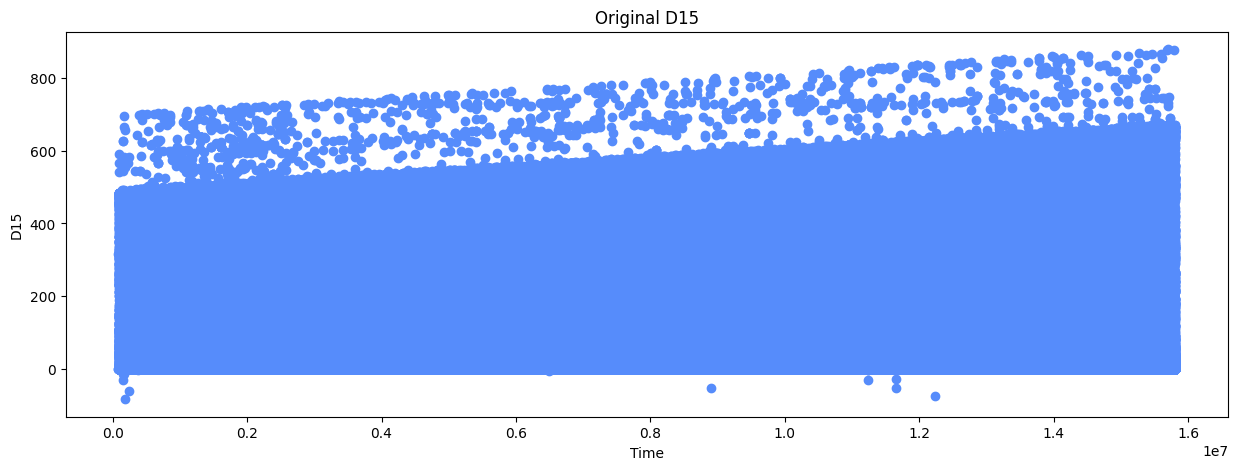

In [34]:
# PLOT ORIGINAL D
plt.figure(figsize=(15,5))
plt.scatter(X_train.TransactionDT,X_train.D15)
plt.title('Original D15')
plt.xlabel('Time')
plt.ylabel('D15')
plt.show()

In [35]:
# NORMALIZE D COLUMNS
# for i in range(1,16):
#     if i in [1,2,3,5,9]: continue  # Why?
#     X_train['D'+str(i)] =  X_train['D'+str(i)] - X_train.TransactionDT/np.float32(24*60*60)
#     X_test['D'+str(i)] = X_test['D'+str(i)] - X_test.TransactionDT/np.float32(24*60*60)

for i in range(1, 16):
    if i in [1, 2, 3, 5, 9]:
        continue
    c = f"D{i}"

    X_train[c] = X_train[c] - np.floor(X_train["TransactionDT"] / np.float32(24 * 60 * 60))
    X_test[c]  = X_test[c]  - np.floor(X_test["TransactionDT"]  / np.float32(24 * 60 * 60))


In [36]:
X_train

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000.0,86400.0,68.500000,W,13926.0,NaN,150.0,discover,142.0,credit,315.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987001.0,86401.0,29.000000,W,2755.0,404.0,150.0,mastercard,102.0,credit,325.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987002.0,86469.0,59.000000,W,4663.0,490.0,150.0,visa,166.0,debit,330.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987003.0,86499.0,50.000000,W,18132.0,567.0,150.0,mastercard,117.0,debit,476.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987004.0,86506.0,50.000000,H,4497.0,514.0,150.0,mastercard,102.0,credit,420.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3577535.0,15811047.0,49.000000,W,6550.0,NaN,150.0,visa,226.0,debit,272.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3577536.0,15811049.0,39.500000,W,10444.0,225.0,150.0,mastercard,224.0,debit,204.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3577537.0,15811079.0,30.950001,W,12037.0,595.0,150.0,mastercard,224.0,debit,231.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
X_test

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
3663549.0,18403224.0,31.950001,W,10409.0,111.0,150.0,visa,226.0,debit,170.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663550.0,18403264.0,49.000000,W,4272.0,111.0,150.0,visa,226.0,debit,299.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663551.0,18403310.0,171.000000,W,4476.0,574.0,150.0,visa,226.0,debit,472.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663552.0,18403310.0,284.950012,W,10989.0,360.0,150.0,visa,166.0,debit,205.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663553.0,18403316.0,67.949997,W,18018.0,452.0,150.0,mastercard,117.0,debit,264.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4170235.0,34214280.0,94.679001,C,13832.0,375.0,185.0,mastercard,224.0,debit,284.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4170236.0,34214288.0,12.173000,C,3154.0,408.0,185.0,mastercard,224.0,debit,NaN,...,chrome 43.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,ALE-L23 Build/HuaweiALE-L23
4170237.0,34214328.0,49.000000,W,16661.0,490.0,150.0,visa,226.0,debit,327.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


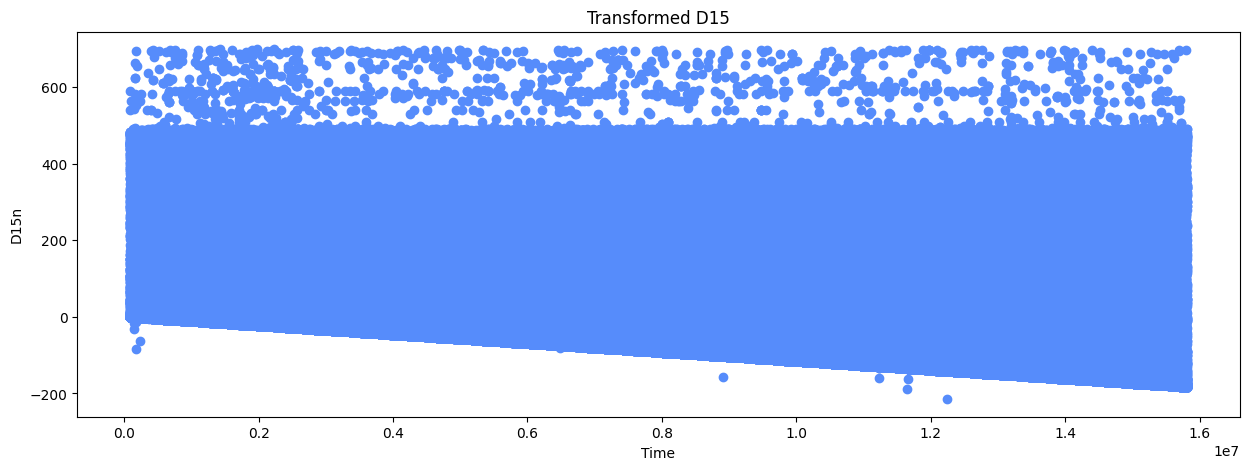

In [38]:
# PLOT TRANSFORMED D
plt.figure(figsize=(15,5))
plt.scatter(X_train.TransactionDT,X_train.D15)
plt.title('Transformed D15')
plt.xlabel('Time')
plt.ylabel('D15n')
plt.show()

In [39]:
numeric_cols = list(set(cols) - set(str_type))
print(numeric_cols)

['D1', 'V188', 'card1', 'V89', 'C3', 'V48', 'V40', 'V169', 'V294', 'V76', 'V124', 'TransactionID', 'V11', 'V162', 'V250', 'V253', 'C11', 'V305', 'C2', 'C1', 'V210', 'V37', 'V198', 'V261', 'D9', 'D15', 'V65', 'V234', 'D8', 'V277', 'V205', 'V182', 'V257', 'V185', 'V62', 'V180', 'V123', 'C7', 'V107', 'V307', 'V271', 'D14', 'V147', 'V121', 'V215', 'V68', 'V301', 'D13', 'V139', 'card2', 'V88', 'V296', 'V209', 'D5', 'V229', 'V221', 'V4', 'V138', 'V13', 'V291', 'V310', 'V56', 'V156', 'D11', 'V284', 'V283', 'V240', 'V27', 'C6', 'V226', 'V289', 'V80', 'V187', 'V160', 'V1', 'V207', 'D12', 'V285', 'V14', 'V228', 'V78', 'V30', 'V111', 'V54', 'V59', 'V235', 'V309', 'V252', 'V44', 'C5', 'C12', 'V220', 'V70', 'dist2', 'TransactionDT', 'C4', 'V320', 'V260', 'D7', 'V36', 'card5', 'D2', 'V286', 'V171', 'V129', 'V130', 'V173', 'V6', 'V120', 'V178', 'D3', 'TransactionAmt', 'addr1', 'V264', 'V297', 'V238', 'V258', 'V47', 'V67', 'C10', 'C9', 'addr2', 'V127', 'V267', 'V108', 'V314', 'V218', 'V17', 'V203', 'V

In [40]:
print("X_train.dtypes:\n", X_train.dtypes)
print("X_test.dtypes:\n", X_test.dtypes)

X_train.dtypes:
 TransactionDT      float32
TransactionAmt     float32
ProductCD         category
card1              float32
card2              float32
                    ...   
id_36             category
id_37             category
id_38             category
DeviceType        category
DeviceInfo        category
Length: 213, dtype: object
X_test.dtypes:
 TransactionDT      float32
TransactionAmt     float32
ProductCD         category
card1              float32
card2              float32
                    ...   
id_36             category
id_37             category
id_38             category
DeviceType        category
DeviceInfo        category
Length: 213, dtype: object


In [41]:
%%time
# LABEL ENCODE AND MEMORY REDUCE
X_train_copy1 = X_train.copy()
X_test_copy1 = X_test.copy()
for f in X_train_copy1.columns:
    if str(X_train_copy1[f].dtype) == "category" or X_train_copy1[f].dtype == "object":
        comb, _ = pd.factorize(pd.concat([X_train_copy1[f], X_test_copy1[f]]), sort=True)
        X_train_copy1[f] = comb[:len(X_train_copy1)].astype("int16")
        X_test_copy1[f]  = comb[len(X_train_copy1):].astype("int16")
    elif f not in ["TransactionAmt", "TransactionDT"]:
        mn = np.min((X_train_copy1[f].min(), X_test_copy1[f].min()))
        X_train_copy1[f] = (X_train_copy1[f] - np.float32(mn)).fillna(-1)
        X_test_copy1[f]  = (X_test_copy1[f]  - np.float32(mn)).fillna(-1)

CPU times: user 1.64 s, sys: 804 ms, total: 2.44 s
Wall time: 3.08 s


In [42]:
print(str_type)

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'id-12', 'id-15', 'id-16', 'id-23', 'id-27', 'id-28', 'id-29', 'id-30', 'id-31', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38']


In [43]:
print(numeric_cols)

['D1', 'V188', 'card1', 'V89', 'C3', 'V48', 'V40', 'V169', 'V294', 'V76', 'V124', 'TransactionID', 'V11', 'V162', 'V250', 'V253', 'C11', 'V305', 'C2', 'C1', 'V210', 'V37', 'V198', 'V261', 'D9', 'D15', 'V65', 'V234', 'D8', 'V277', 'V205', 'V182', 'V257', 'V185', 'V62', 'V180', 'V123', 'C7', 'V107', 'V307', 'V271', 'D14', 'V147', 'V121', 'V215', 'V68', 'V301', 'D13', 'V139', 'card2', 'V88', 'V296', 'V209', 'D5', 'V229', 'V221', 'V4', 'V138', 'V13', 'V291', 'V310', 'V56', 'V156', 'D11', 'V284', 'V283', 'V240', 'V27', 'C6', 'V226', 'V289', 'V80', 'V187', 'V160', 'V1', 'V207', 'D12', 'V285', 'V14', 'V228', 'V78', 'V30', 'V111', 'V54', 'V59', 'V235', 'V309', 'V252', 'V44', 'C5', 'C12', 'V220', 'V70', 'dist2', 'TransactionDT', 'C4', 'V320', 'V260', 'D7', 'V36', 'card5', 'D2', 'V286', 'V171', 'V129', 'V130', 'V173', 'V6', 'V120', 'V178', 'D3', 'TransactionAmt', 'addr1', 'V264', 'V297', 'V238', 'V258', 'V47', 'V67', 'C10', 'C9', 'addr2', 'V127', 'V267', 'V108', 'V314', 'V218', 'V17', 'V203', 'V

In [44]:
print(numeric_cols)
# keep only columns that actually exist in X_train_copy1
num_cols = [c for c in numeric_cols if c in X_train.columns]

# NaN count per numeric column
na_counts = X_train[num_cols].isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)

print(na_counts)

['D1', 'V188', 'card1', 'V89', 'C3', 'V48', 'V40', 'V169', 'V294', 'V76', 'V124', 'TransactionID', 'V11', 'V162', 'V250', 'V253', 'C11', 'V305', 'C2', 'C1', 'V210', 'V37', 'V198', 'V261', 'D9', 'D15', 'V65', 'V234', 'D8', 'V277', 'V205', 'V182', 'V257', 'V185', 'V62', 'V180', 'V123', 'C7', 'V107', 'V307', 'V271', 'D14', 'V147', 'V121', 'V215', 'V68', 'V301', 'D13', 'V139', 'card2', 'V88', 'V296', 'V209', 'D5', 'V229', 'V221', 'V4', 'V138', 'V13', 'V291', 'V310', 'V56', 'V156', 'D11', 'V284', 'V283', 'V240', 'V27', 'C6', 'V226', 'V289', 'V80', 'V187', 'V160', 'V1', 'V207', 'D12', 'V285', 'V14', 'V228', 'V78', 'V30', 'V111', 'V54', 'V59', 'V235', 'V309', 'V252', 'V44', 'C5', 'C12', 'V220', 'V70', 'dist2', 'TransactionDT', 'C4', 'V320', 'V260', 'D7', 'V36', 'card5', 'D2', 'V286', 'V171', 'V129', 'V130', 'V173', 'V6', 'V120', 'V178', 'D3', 'TransactionAmt', 'addr1', 'V264', 'V297', 'V238', 'V258', 'V47', 'V67', 'C10', 'C9', 'addr2', 'V127', 'V267', 'V108', 'V314', 'V218', 'V17', 'V203', 'V

In [45]:
# keep only columns that actually exist in X_train_copy1
num_cols = [c for c in numeric_cols if c in X_train_copy1.columns]

# NaN count per numeric column
na_counts = X_train_copy1[num_cols].isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)

print(na_counts)

Series([], dtype: int64)


In [46]:
# Check column that remains NaN
print(X_train.isna().sum()[X_train.isna().sum() > 0])
print(X_test.isna().sum()[X_test.isna().sum() > 0])

card2           8933
card3           1565
card4           1577
card5           4259
card6           1571
               ...  
id_36         449555
id_37         449555
id_38         449555
DeviceType    449730
DeviceInfo    471874
Length: 195, dtype: int64
card2           8654
card3           3002
card4           3086
card5           4547
card6           3007
               ...  
id_36         369714
id_37         369714
id_38         369714
DeviceType    369760
DeviceInfo    391634
Length: 196, dtype: int64


In [47]:
# Check column that remains NaN
print(X_train_copy1.isna().sum()[X_train_copy1.isna().sum() > 0])
print(X_test_copy1.isna().sum()[X_test_copy1.isna().sum() > 0])

Series([], dtype: int64)
Series([], dtype: int64)


In [48]:
# Returns True if at least one null exists in 'column_name'
has_nulls = X_test_copy1['D11'].isna().any()
print(has_nulls)

False


In [49]:
print("X_train_copy.dtypes:\n", X_train.dtypes)
print("X_test_copy.dtypes:\n", X_test.dtypes)

X_train_copy.dtypes:
 TransactionDT      float32
TransactionAmt     float32
ProductCD         category
card1              float32
card2              float32
                    ...   
id_36             category
id_37             category
id_38             category
DeviceType        category
DeviceInfo        category
Length: 213, dtype: object
X_test_copy.dtypes:
 TransactionDT      float32
TransactionAmt     float32
ProductCD         category
card1              float32
card2              float32
                    ...   
id_36             category
id_37             category
id_38             category
DeviceType        category
DeviceInfo        category
Length: 213, dtype: object


In [50]:
print("X_train_copy1.dtypes:\n", X_train_copy1.dtypes)
print("X_test_copy1.dtypes:\n", X_test_copy1.dtypes)

X_train_copy1.dtypes:
 TransactionDT     float32
TransactionAmt    float32
ProductCD           int16
card1             float32
card2             float32
                   ...   
id_36               int16
id_37               int16
id_38               int16
DeviceType          int16
DeviceInfo          int16
Length: 213, dtype: object
X_test_copy1.dtypes:
 TransactionDT     float32
TransactionAmt    float32
ProductCD           int16
card1             float32
card2             float32
                   ...   
id_36               int16
id_37               int16
id_38               int16
DeviceType          int16
DeviceInfo          int16
Length: 213, dtype: object


In [51]:
d_cols = X_train_copy1.columns[X_train_copy1.columns.str.match(r"^D\d+$")]
print(X_train_copy1[d_cols].dtypes)

D1     float32
D2     float32
D3     float32
D4     float32
D5     float32
D6     float32
D7     float32
D8     float32
D9     float32
D10    float32
D11    float32
D12    float32
D13    float32
D14    float32
D15    float32
dtype: object


In [52]:
X_train

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000.0,86400.0,68.500000,W,13926.0,NaN,150.0,discover,142.0,credit,315.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987001.0,86401.0,29.000000,W,2755.0,404.0,150.0,mastercard,102.0,credit,325.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987002.0,86469.0,59.000000,W,4663.0,490.0,150.0,visa,166.0,debit,330.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987003.0,86499.0,50.000000,W,18132.0,567.0,150.0,mastercard,117.0,debit,476.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987004.0,86506.0,50.000000,H,4497.0,514.0,150.0,mastercard,102.0,credit,420.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3577535.0,15811047.0,49.000000,W,6550.0,NaN,150.0,visa,226.0,debit,272.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3577536.0,15811049.0,39.500000,W,10444.0,225.0,150.0,mastercard,224.0,debit,204.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3577537.0,15811079.0,30.950001,W,12037.0,595.0,150.0,mastercard,224.0,debit,231.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
X_train_copy1

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000.0,86400.0,68.500000,4,12926.0,-1.0,50.0,1,42.0,1,215.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
2987001.0,86401.0,29.000000,4,1755.0,304.0,50.0,2,2.0,1,225.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
2987002.0,86469.0,59.000000,4,3663.0,390.0,50.0,3,66.0,2,230.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
2987003.0,86499.0,50.000000,4,17132.0,467.0,50.0,2,17.0,2,376.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
2987004.0,86506.0,50.000000,1,3497.0,414.0,50.0,2,2.0,1,320.0,...,161,32.0,268,3,1,0,1,1,1,1565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3577535.0,15811047.0,49.000000,4,5550.0,-1.0,50.0,3,126.0,2,172.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
3577536.0,15811049.0,39.500000,4,9444.0,125.0,50.0,2,124.0,2,104.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
3577537.0,15811079.0,30.950001,4,11037.0,495.0,50.0,2,124.0,2,131.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1


In [54]:
X_test

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
3663549.0,18403224.0,31.950001,W,10409.0,111.0,150.0,visa,226.0,debit,170.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663550.0,18403264.0,49.000000,W,4272.0,111.0,150.0,visa,226.0,debit,299.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663551.0,18403310.0,171.000000,W,4476.0,574.0,150.0,visa,226.0,debit,472.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663552.0,18403310.0,284.950012,W,10989.0,360.0,150.0,visa,166.0,debit,205.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663553.0,18403316.0,67.949997,W,18018.0,452.0,150.0,mastercard,117.0,debit,264.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4170235.0,34214280.0,94.679001,C,13832.0,375.0,185.0,mastercard,224.0,debit,284.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4170236.0,34214288.0,12.173000,C,3154.0,408.0,185.0,mastercard,224.0,debit,NaN,...,chrome 43.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,ALE-L23 Build/HuaweiALE-L23
4170237.0,34214328.0,49.000000,W,16661.0,490.0,150.0,visa,226.0,debit,327.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
X_test_copy1

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
3663549.0,18403224.0,31.950001,4,9409.0,11.0,50.0,3,126.0,2,70.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
3663550.0,18403264.0,49.000000,4,3272.0,11.0,50.0,3,126.0,2,199.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
3663551.0,18403310.0,171.000000,4,3476.0,474.0,50.0,3,126.0,2,372.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
3663552.0,18403310.0,284.950012,4,9989.0,260.0,50.0,3,66.0,2,105.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
3663553.0,18403316.0,67.949997,4,17018.0,352.0,50.0,2,17.0,2,164.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4170235.0,34214280.0,94.679001,0,12832.0,275.0,85.0,2,124.0,2,184.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
4170236.0,34214288.0,12.173000,0,2154.0,308.0,85.0,2,124.0,2,-1.0,...,22,-1.0,-1,-1,0,0,1,0,1,141
4170237.0,34214328.0,49.000000,4,15661.0,390.0,50.0,3,126.0,2,227.0,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1


# ENCODING FUNCTIONS
Below are 5 encoding functions. (1) encode_FE does frequency encoding where it combines train and test first and then encodes. (2) encode_LE is a label encoded for categorical features (3) encode_AG makes aggregated features such as aggregated mean and std (4) encode_CB combines two columns (5) encode_AG2 makes aggregated features where it counts how many unique values of one feature is within a group. For more explanation about feature engineering, see the discussion

In [56]:
X_train_copy2 = X_train_copy1.copy()
X_test_copy2 = X_test_copy1.copy()

In [57]:
temp = X_train_copy1['card1'].value_counts().to_dict()
# X_train_copy1['card1_counts'] = X_train_copy1['card1'].map(temp)

In [58]:
print(temp)

{6919.0: 14932, 8500.0: 14162, 14885.0: 10361, 16188.0: 10344, 14066.0: 7945, 11695.0: 7091, 11544.0: 6773, 5019.0: 6771, 1803.0: 6141, 6585.0: 5334, 9616.0: 5172, 11839.0: 5129, 2154.0: 4614, 1616.0: 4410, 17132.0: 4209, 8633.0: 4158, 14497.0: 3977, 15132.0: 3929, 1884.0: 3873, 15075.0: 3748, 10207.0: 3693, 9112.0: 3560, 6508.0: 3490, 9057.0: 3166, 11501.0: 3152, 6826.0: 3006, 15659.0: 2988, 11577.0: 2891, 4812.0: 2818, 6664.0: 2792, 6861.0: 2774, 5530.0: 2714, 3461.0: 2686, 7320.0: 2632, 4033.0: 2604, 6207.0: 2578, 14063.0: 2522, 9486.0: 2505, 9023.0: 2428, 6815.0: 2411, 8112.0: 2364, 15560.0: 2080, 8026.0: 2076, 15136.0: 2069, 3806.0: 2067, 12832.0: 2062, 6676.0: 2038, 11932.0: 1998, 444.0: 1964, 3436.0: 1947, 10839.0: 1940, 16399.0: 1916, 1772.0: 1898, 1455.0: 1799, 675.0: 1790, 13290.0: 1767, 10157.0: 1722, 2821.0: 1681, 16055.0: 1677, 893.0: 1651, 974.0: 1591, 16131.0: 1587, 17018.0: 1569, 724.0: 1567, 8803.0: 1538, 7528.0: 1523, 1392.0: 1509, 14775.0: 1503, 12249.0: 1492, 16400.

In [59]:
# FREQUENCY ENCODE TOGETHER
def encode_FE(df1, df2, cols):
    for col in cols:
        df = pd.concat([df1[col],df2[col]])
        vc = df.value_counts(dropna=True, normalize=False).to_dict()
        vc[-1] = -1
        nm = col+'_FE'
        df1[nm] = df1[col].map(vc)
        df1[nm] = df1[nm].astype('float32')
        df2[nm] = df2[col].map(vc)
        df2[nm] = df2[nm].astype('float32')
        print(nm,', ',end='')

In [60]:
# LABEL ENCODE
# def encode_LE(col,train=X_train_copy1,test=X_test_copy1,verbose=True):
#     df_comb = pd.concat([train[col],test[col]],axis=0)
#     df_comb,_ = df_comb.factorize(sort=True)
#     nm = col
#     if df_comb.max()>32000:
#         train[nm] = df_comb[:len(train)].astype('int32')
#         test[nm] = df_comb[len(train):].astype('int32')
#     else:
#         train[nm] = df_comb[:len(train)].astype('int16')
#         test[nm] = df_comb[len(train):].astype('int16')
#     del df_comb; x=gc.collect()
#     if verbose: print(nm,', ',end='')

def encode_LE(col, train=X_train_copy2, test=X_test_copy2, verbose=True):
    df_comb = pd.concat([train[col], test[col]], axis=0)
    df_comb, _ = df_comb.factorize(sort=True)

    if df_comb.max() > 32000:
        train_vals = df_comb[:len(train)].astype("int32")
        test_vals = df_comb[len(train):].astype("int32")
    else:
        train_vals = df_comb[:len(train)].astype("int16")
        test_vals = df_comb[len(train):].astype("int16")

    train = _set_col_no_fragment(train, col, train_vals)
    test = _set_col_no_fragment(test, col, test_vals)

    del df_comb
    gc.collect()
    if verbose:
        print(col, ", ", end="")
    return train, test

In [61]:
# COMBINE FEATURES
# def encode_CB(col1,col2,df1=X_train_copy1,df2=X_test_copy1):
#     nm = col1+'_'+col2
#     df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
#     df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str)
#     encode_LE(nm,verbose=False)
#     print(nm,', ',end='')


def encode_CB(col1, col2, df1=X_train_copy2, df2=X_test_copy2):
    nm = col1 + "_" + col2

    cb1 = df1[col1].astype(str) + "_" + df1[col2].astype(str)
    cb2 = df2[col1].astype(str) + "_" + df2[col2].astype(str)

    df1 = _set_col_no_fragment(df1, nm, cb1)
    df2 = _set_col_no_fragment(df2, nm, cb2)

    # keep original logic: CB -> LE
    df1, df2 = encode_LE(nm, train=df1, test=df2, verbose=False)
    print(nm, ", ", end="")
    return df1, df2

In [62]:
def _set_col_no_fragment(df, col, values):
    s = pd.Series(values, index=df.index, name=col)
    if col in df.columns:
        df[col] = s.to_numpy()   # replace whole column; dtype can change
        return df
    return pd.concat([df, s], axis=1)

In [63]:
# GROUP AGGREGATION MEAN AND STD
# https://www.kaggle.com/kyakovlev/ieee-fe-with-some-eda
def encode_AG(main_columns, uids, aggregations=['mean'], train_df=X_train_copy2, test_df=X_test_copy2,
              fillna=True, usena=False):
    # AGGREGATION OF MAIN WITH UID FOR GIVEN STATISTICS
    for main_column in main_columns:
        for col in uids:
            for agg_type in aggregations:
                new_col_name = main_column+'_'+col+'_'+agg_type
                temp_df = pd.concat([train_df[[col, main_column]], test_df[[col,main_column]]])
                if usena: temp_df.loc[temp_df[main_column]==-1,main_column] = -1
                temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
                                                        columns={agg_type: new_col_name})

                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_col_name].to_dict()

                train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
                test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')

                if fillna:
                    train_df[new_col_name].fillna(-1,inplace=True)
                    test_df[new_col_name].fillna(-1,inplace=True)

                print("'"+new_col_name+"'",', ',end='')

In [64]:
# GROUP AGGREGATION NUNIQUE
def encode_AG2(main_columns, uids, train_df=X_train_copy2, test_df=X_test_copy2):
    for main_column in main_columns:
        for col in uids:
            comb = pd.concat([train_df[[col]+[main_column]],test_df[[col]+[main_column]]],axis=0)
            mp = comb.groupby(col)[main_column].agg(['nunique'])['nunique'].to_dict()
            train_df[col+'_'+main_column+'_ct'] = train_df[col].map(mp).astype('float32')
            test_df[col+'_'+main_column+'_ct'] = test_df[col].map(mp).astype('float32')
            print(col+'_'+main_column+'_ct, ',end='')

# Feature Engineering
We will now engineer features. All of these features where chosen because each increases local validation. The procedure for engineering features is as follows. First you think of an idea and create a new feature. Then you add it to your model and evaluate whether local validation AUC increases or decreases. If AUC increases keep the feature, otherwise discard the feature.

In [65]:
train_new = pd.DataFrame({
    "cents": (X_train_copy2["TransactionAmt"] - np.floor(X_train_copy2["TransactionAmt"])).astype("float32"),
    "dollars": np.floor(X_train_copy2["TransactionAmt"]).astype("float32"),
}, index=X_train_copy2.index)

test_new = pd.DataFrame({
    "cents": (X_test_copy2["TransactionAmt"] - np.floor(X_test_copy2["TransactionAmt"])).astype("float32"),
    "dollars": np.floor(X_test_copy2["TransactionAmt"]).astype("float32"),
}, index=X_test_copy2.index)

X_train_copy2 = pd.concat([X_train_copy2, train_new], axis=1)
X_test_copy2 = pd.concat([X_test_copy2, test_new], axis=1)

In [66]:
X_train_copy2

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,cents,dollars
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000.0,86400.0,68.500000,4,12926.0,-1.0,50.0,1,42.0,1,215.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.500000,68.0
2987001.0,86401.0,29.000000,4,1755.0,304.0,50.0,2,2.0,1,225.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.000000,29.0
2987002.0,86469.0,59.000000,4,3663.0,390.0,50.0,3,66.0,2,230.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.000000,59.0
2987003.0,86499.0,50.000000,4,17132.0,467.0,50.0,2,17.0,2,376.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.000000,50.0
2987004.0,86506.0,50.000000,1,3497.0,414.0,50.0,2,2.0,1,320.0,...,268,3,1,0,1,1,1,1565,0.000000,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3577535.0,15811047.0,49.000000,4,5550.0,-1.0,50.0,3,126.0,2,172.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.000000,49.0
3577536.0,15811049.0,39.500000,4,9444.0,125.0,50.0,2,124.0,2,104.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.500000,39.0
3577537.0,15811079.0,30.950001,4,11037.0,495.0,50.0,2,124.0,2,131.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.950001,30.0


In [67]:
X_test_copy2

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,cents,dollars
TransactionID,,,,,,,,,,,,,,,,,,,,,
3663549.0,18403224.0,31.950001,4,9409.0,11.0,50.0,3,126.0,2,70.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.950001,31.0
3663550.0,18403264.0,49.000000,4,3272.0,11.0,50.0,3,126.0,2,199.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.000000,49.0
3663551.0,18403310.0,171.000000,4,3476.0,474.0,50.0,3,126.0,2,372.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.000000,171.0
3663552.0,18403310.0,284.950012,4,9989.0,260.0,50.0,3,66.0,2,105.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.950012,284.0
3663553.0,18403316.0,67.949997,4,17018.0,352.0,50.0,2,17.0,2,164.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.949997,67.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4170235.0,34214280.0,94.679001,0,12832.0,275.0,85.0,2,124.0,2,184.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.679001,94.0
4170236.0,34214288.0,12.173000,0,2154.0,308.0,85.0,2,124.0,2,-1.0,...,-1,-1,0,0,1,0,1,141,0.173000,12.0
4170237.0,34214328.0,49.000000,4,15661.0,390.0,50.0,3,126.0,2,227.0,...,-1,-1,-1,-1,-1,-1,-1,-1,0.000000,49.0


In [68]:
print(X_train_copy2.dtypes)
print(X_test_copy2.dtypes)

TransactionDT     float32
TransactionAmt    float32
ProductCD           int16
card1             float32
card2             float32
                   ...   
id_38               int16
DeviceType          int16
DeviceInfo          int16
cents             float32
dollars           float32
Length: 215, dtype: object
TransactionDT     float32
TransactionAmt    float32
ProductCD           int16
card1             float32
card2             float32
                   ...   
id_38               int16
DeviceType          int16
DeviceInfo          int16
cents             float32
dollars           float32
Length: 215, dtype: object


In [69]:
# FREQUENCY ENCODE: ADDR1, CARD1, CARD2, CARD3, P_EMAIL_DOMAIN
encode_FE(X_train_copy2,X_test_copy2,['addr1','card1','card2','card3','P_emaildomain'])

addr1_FE , card1_FE , card2_FE , card3_FE , P_emaildomain_FE , 

In [70]:
# COMBINE COLUMNS CARD1+ADDR1, CARD1+ADDR1+P_EMAILDOMAIN
X_train_copy2, X_test_copy2 = encode_CB("card1", "addr1", X_train_copy2, X_test_copy2)

card1_addr1 , 

In [71]:
X_train_copy2, X_test_copy2 = encode_CB('card1_addr1','P_emaildomain', X_train_copy2, X_test_copy2)

card1_addr1_P_emaildomain , 

In [72]:
# FREQUENCY ENOCDE
encode_FE(X_train_copy2,X_test_copy2,['card1_addr1','card1_addr1_P_emaildomain'])

card1_addr1_FE , card1_addr1_P_emaildomain_FE , 

In [73]:
print('card1_addr1' in X_train_copy2.columns, 'card1_addr1_P_emaildomain' in X_train_copy2.columns)
print('card1_addr1' in X_test_copy2.columns, 'card1_addr1_P_emaildomain' in X_test_copy2.columns)

True True
True True


In [74]:
# GROUP AGGREGATE
encode_AG(
    ['TransactionAmt','D9','D11'],
    ['card1','card1_addr1','card1_addr1_P_emaildomain'],
    ['mean','std'],
    train_df=X_train_copy2,
    test_df=X_test_copy2,
    usena=True,
    fillna=True,
)

'TransactionAmt_card1_mean' , 'TransactionAmt_card1_std' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'TransactionAmt_card1_addr1_mean' , 'TransactionAmt_card1_addr1_std' , 'TransactionAmt_card1_addr1_P_emaildomain_mean' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'TransactionAmt_card1_addr1_P_emaildomain_std' , 'D9_card1_mean' , 'D9_card1_std' , 

...

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'D11_card1_mean' , 'D11_card1_std' , 'D11_card1_addr1_mean' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'D11_card1_addr1_std' , 'D11_card1_addr1_P_emaildomain_mean' , 'D11_card1_addr1_P_emaildomain_std' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

In [75]:
print(X_train_copy2['card1_addr1'].dtypes)
print(X_train_copy2['card1_addr1_P_emaildomain'].dtypes)

int32
int32


In [76]:
X_train_copy2

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,D9_card1_addr1_mean,D9_card1_addr1_std,D9_card1_addr1_P_emaildomain_mean,D9_card1_addr1_P_emaildomain_std,D11_card1_mean,D11_card1_std,D11_card1_addr1_mean,D11_card1_addr1_std,D11_card1_addr1_P_emaildomain_mean,D11_card1_addr1_P_emaildomain_std
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000.0,86400.0,68.500000,4,12926.0,-1.0,50.0,1,42.0,1,215.0,...,-1.000000,0.000000,-1.000000,NaN,107.232140,147.501373,135.000000,235.558914,407.000000,NaN
2987001.0,86401.0,29.000000,4,1755.0,304.0,50.0,2,2.0,1,225.0,...,-0.931464,0.318573,-0.831349,0.532694,283.922272,272.640289,174.345795,191.249023,135.523804,232.641266
2987002.0,86469.0,59.000000,4,3663.0,390.0,50.0,3,66.0,2,230.0,...,-1.000000,0.000000,-1.000000,0.000000,233.691193,205.770935,255.787231,245.273849,709.500000,0.577350
2987003.0,86499.0,50.000000,4,17132.0,467.0,50.0,2,17.0,2,376.0,...,-0.980372,0.186756,-0.987676,0.146857,287.958740,270.869965,236.683197,268.158569,143.021133,238.531342
2987004.0,86506.0,50.000000,1,3497.0,414.0,50.0,2,2.0,1,320.0,...,-1.000000,NaN,-1.000000,NaN,258.833344,285.902802,-1.000000,NaN,-1.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3577535.0,15811047.0,49.000000,4,5550.0,-1.0,50.0,3,126.0,2,172.0,...,-0.900000,0.415218,-1.000000,0.000000,287.315155,240.272888,260.514282,201.871735,325.200012,137.121109
3577536.0,15811049.0,39.500000,4,9444.0,125.0,50.0,2,124.0,2,104.0,...,-0.935000,0.325000,-1.000000,0.000000,358.519989,319.291534,358.519989,319.291534,103.800003,62.794903
3577537.0,15811079.0,30.950001,4,11037.0,495.0,50.0,2,124.0,2,131.0,...,-0.948936,0.280628,-0.930556,0.317901,295.091034,261.110535,296.292542,250.740051,264.507385,230.064972


In [77]:
X_test_copy2

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,D9_card1_addr1_mean,D9_card1_addr1_std,D9_card1_addr1_P_emaildomain_mean,D9_card1_addr1_P_emaildomain_std,D11_card1_mean,D11_card1_std,D11_card1_addr1_mean,D11_card1_addr1_std,D11_card1_addr1_P_emaildomain_mean,D11_card1_addr1_P_emaildomain_std
TransactionID,,,,,,,,,,,,,,,,,,,,,
3663549.0,18403224.0,31.950001,4,9409.0,11.0,50.0,3,126.0,2,70.0,...,-1.000000,0.000000,-1.000000,0.000000,385.293335,278.172546,429.238098,273.892792,332.125000,157.626694
3663550.0,18403264.0,49.000000,4,3272.0,11.0,50.0,3,126.0,2,199.0,...,-0.871477,0.437993,-0.920549,0.356055,284.314392,294.725555,291.363373,297.773376,404.105591,304.532288
3663551.0,18403310.0,171.000000,4,3476.0,474.0,50.0,3,126.0,2,372.0,...,-0.948293,0.274971,-1.000000,0.000000,341.602417,282.377930,341.602417,282.377930,309.600006,130.597946
3663552.0,18403310.0,284.950012,4,9989.0,260.0,50.0,3,66.0,2,105.0,...,-1.000000,0.000000,-1.000000,0.000000,235.688156,209.823196,225.516129,169.324509,199.740738,162.110733
3663553.0,18403316.0,67.949997,4,17018.0,352.0,50.0,2,17.0,2,164.0,...,-0.991450,0.121101,-0.987171,0.145517,279.181274,247.039459,287.721222,251.457733,281.453217,245.703705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4170235.0,34214280.0,94.679001,0,12832.0,275.0,85.0,2,124.0,2,184.0,...,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000
4170236.0,34214288.0,12.173000,0,2154.0,308.0,85.0,2,124.0,2,-1.0,...,-0.310623,0.782657,-0.341525,0.779522,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000
4170237.0,34214328.0,49.000000,4,15661.0,390.0,50.0,3,126.0,2,227.0,...,-0.882697,0.425558,-0.896242,0.422572,229.288162,251.471451,233.174698,245.264023,113.529411,107.526810


In [78]:
print(X_train_copy2.dtypes)

TransactionDT                         float32
TransactionAmt                        float32
ProductCD                               int16
card1                                 float32
card2                                 float32
                                       ...   
D11_card1_std                         float32
D11_card1_addr1_mean                  float32
D11_card1_addr1_std                   float32
D11_card1_addr1_P_emaildomain_mean    float32
D11_card1_addr1_P_emaildomain_std     float32
Length: 242, dtype: object


In [79]:
# Check column that remains NaN
print(X_train_copy2.isna().sum()[X_train_copy2.isna().sum() > 0])
print(X_test_copy2.isna().sum()[X_test_copy2.isna().sum() > 0])

TransactionAmt_card1_std                         2053
TransactionAmt_card1_addr1_std                  11134
TransactionAmt_card1_addr1_P_emaildomain_std    33390
D9_card1_std                                     2053
D9_card1_addr1_std                              11134
D9_card1_addr1_P_emaildomain_std                33390
D11_card1_std                                    2053
D11_card1_addr1_std                             11134
D11_card1_addr1_P_emaildomain_std               33390
dtype: int64
TransactionAmt_card1_std                         1974
TransactionAmt_card1_addr1_std                  10112
TransactionAmt_card1_addr1_P_emaildomain_std    27594
D9_card1_std                                     1974
D9_card1_addr1_std                              10112
D9_card1_addr1_P_emaildomain_std                27594
D11_card1_std                                    1974
D11_card1_addr1_std                             10112
D11_card1_addr1_P_emaildomain_std               27594
dtype: int64


In [80]:
X_train_copy3 = X_train_copy2.copy()
X_test_copy3 = X_test_copy2.copy()

In [81]:
# std columns: singleton groups -> fill 0 is common
std_cols = [c for c in X_train_copy3.columns if c.endswith("_std")]
for c in std_cols:
    X_train_copy3[c] = X_train_copy3[c].fillna(0)
    X_test_copy3[c]  = X_test_copy3[c].fillna(0)

# mean columns: fill with train global mean per base variable (example for D9/D11 means)
for c in [x for x in X_train_copy3.columns if x.endswith("_mean")]:
    fill_val = X_train_copy3[c].mean()
    X_train_copy3[c] = X_train_copy3[c].fillna(fill_val)
    # X_train_copy3[c + "_isna"] = X_train_copy3[c].isna().astype("int8")

    X_test_copy3[c]  = X_test_copy3[c].fillna(fill_val)
    # X_test_copy3[c + "_isna"]  = X_test_copy3[c].isna().astype("int8")

In [82]:
# Check column that remains NaN
print(X_train_copy3.isna().sum()[X_train_copy3.isna().sum() > 0])
print(X_test_copy3.isna().sum()[X_test_copy3.isna().sum() > 0])

Series([], dtype: int64)
Series([], dtype: int64)


# Feature Selection - Time Consistency
We added 28 new feature above. We have already removed 219 V Columns from correlation analysis done here. So we currently have 242 features now. We will now check each of our 242 for "time consistency". We will build 242 models. Each model will be trained on the first month of the training data and will only use one feature. We will then predict the last month of the training data. We want both training AUC and validation AUC to be above AUC = 0.5. It turns out that 19 features fail this test so we will remove them. Additionally we will remove 7 D columns that are mostly NAN. More techniques for feature selection are listed

In [83]:
cols = list(X_train_copy3.columns )
cols.remove('TransactionDT')
for c in ['D6','D7','D8','D9','D12','D13','D14']:
    cols.remove(c)

# FAILED TIME CONSISTENCY TEST
for c in ['C3','M5','id_08','id_33']:
    cols.remove(c)
for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
    cols.remove(c)
for c in ['id_'+str(x) for x in range(22,28)]:
    cols.remove(c)

In [84]:
print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
np.array(cols)

NOW USING THE FOLLOWING 217 FEATURES.


array(['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card5',
       'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain',
       'R_emaildomain', 'C1', 'C2', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9',
       'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5',
       'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4', 'M6', 'M7', 'M8',
       'M9', 'V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13', 'V14', 'V17',
       'V20', 'V23', 'V26', 'V27', 'V30', 'V36', 'V37', 'V40', 'V41',
       'V44', 'V47', 'V48', 'V54', 'V56', 'V59', 'V62', 'V65', 'V67',
       'V68', 'V70', 'V76', 'V78', 'V80', 'V82', 'V86', 'V88', 'V89',
       'V91', 'V107', 'V108', 'V111', 'V115', 'V117', 'V120', 'V121',
       'V123', 'V124', 'V127', 'V129', 'V130', 'V136', 'V138', 'V139',
       'V142', 'V147', 'V156', 'V160', 'V162', 'V165', 'V166', 'V169',
       'V171', 'V173', 'V175', 'V176', 'V178', 'V180', 'V182', 'V185',
       'V187', 'V188', 'V198', 'V203', 'V205', 'V207', 'V209', 'V210',
       '

# Local Validation
For this competition, we used time based local validation. I evaluated features by training on the first 75% of the data and predicting the last 25% of the data. Konstantin had a slightly different local validation. He trained on the first 4 months, skipped a month, and predicted the last month. Our current XGB model with 216 features achieves AUC = 0.9363 on Chris' local validation and AUC = 0.9241 on Konstantin's local validation. Note that this is the same AUC that Konstantin's LGBM achieves without magic that he posted here and here.

In [85]:
# CHRIS - TRAIN 75% PREDICT 25%
idxT = X_train_copy3.index[:3*len(X_train_copy3)//4]
idxV = X_train_copy3.index[3*len(X_train_copy3)//4:]

# KONSTANTIN - TRAIN 4 SKIP 1 PREDICT 1 MONTH
#idxT = X_train.index[:417559]
#idxV = X_train.index[-89326:]

In [86]:
import xgboost as xgb
# print("XGBoost version:", xgb.__version__)
#
# if BUILD95:
#     clf = xgb.XGBClassifier(
#         n_estimators=2000,
#         max_depth=12,
#         learning_rate=0.02,
#         subsample=0.8,
#         colsample_bytree=0.4,
#         missing=-1,
#         eval_metric="auc",
#         tree_method="hist",      # CPU histogram algorithm
#         device="cpu",
#         early_stopping_rounds=100
#     )
#     h = clf.fit(
#         X_train_copy3.loc[idxT, cols],
#         y_train[idxT],
#         eval_set=[(X_train_copy3.loc[idxV, cols], y_train[idxV])],
#         verbose=50
#     )
#     print("Best iteration:", h.best_iteration)
#     print("Best score:", h.best_score)

In [87]:
# if BUILD95:
#
#     feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_,cols)), columns=['Value','Feature'])
#     plt.figure(figsize=(20, 10))
#     sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:50])
#     plt.title('XGB95 Most Important Features')
#     plt.tight_layout()
#     plt.show()
#     del clf, h; x=gc.collect()

# Predict test.csv
We will predict test.csv using GroupKFold with months as groups. The training data are the months December 2017, January 2018, February 2018, March 2018, April 2018, and May 2018. We refer to these months as 12, 13, 14, 15, 16, 17. Fold one in GroupKFold will train on months 13 thru 17 and predict month 12. Note that the only purpose of month 12 is to tell XGB when to early_stop we don't actual care about the backwards time predictions. The model trained on months 13 thru 17 will also predict test.csv which is forward in time.

Note that we use local validation to determine features but GroupKFold to predict test.csv. Many other prediction schemes were tried but GroupKFold performed best.

In [88]:
import datetime
START_DATE = datetime.datetime.strptime('2017-11-30', '%Y-%m-%d')
X_train_copy3['DT_M'] = X_train_copy3['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))
X_train_copy3['DT_M'] = (X_train_copy3['DT_M'].dt.year-2017)*12 + X_train_copy3['DT_M'].dt.month

X_test_copy3['DT_M'] = X_test_copy3['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))
X_test_copy3['DT_M'] = (X_test_copy3['DT_M'].dt.year-2017)*12 + X_test_copy3['DT_M'].dt.month

In [89]:
non_v_cols_train = [c for c in X_train_copy3.columns if not c.startswith('V')]
non_v_cols_test = [c for c in X_test_copy3.columns if not c.startswith('V')]

X_train_copy6 = X_train_copy3[non_v_cols_train].copy()
X_test_copy6 = X_test_copy3[non_v_cols_test].copy()

In [90]:
X_train_copy3

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,D9_card1_addr1_std,D9_card1_addr1_P_emaildomain_mean,D9_card1_addr1_P_emaildomain_std,D11_card1_mean,D11_card1_std,D11_card1_addr1_mean,D11_card1_addr1_std,D11_card1_addr1_P_emaildomain_mean,D11_card1_addr1_P_emaildomain_std,DT_M
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000.0,86400.0,68.500000,4,12926.0,-1.0,50.0,1,42.0,1,215.0,...,0.000000,-1.000000,0.000000,107.232140,147.501373,135.000000,235.558914,407.000000,0.000000,12
2987001.0,86401.0,29.000000,4,1755.0,304.0,50.0,2,2.0,1,225.0,...,0.318573,-0.831349,0.532694,283.922272,272.640289,174.345795,191.249023,135.523804,232.641266,12
2987002.0,86469.0,59.000000,4,3663.0,390.0,50.0,3,66.0,2,230.0,...,0.000000,-1.000000,0.000000,233.691193,205.770935,255.787231,245.273849,709.500000,0.577350,12
2987003.0,86499.0,50.000000,4,17132.0,467.0,50.0,2,17.0,2,376.0,...,0.186756,-0.987676,0.146857,287.958740,270.869965,236.683197,268.158569,143.021133,238.531342,12
2987004.0,86506.0,50.000000,1,3497.0,414.0,50.0,2,2.0,1,320.0,...,0.000000,-1.000000,0.000000,258.833344,285.902802,-1.000000,0.000000,-1.000000,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3577535.0,15811047.0,49.000000,4,5550.0,-1.0,50.0,3,126.0,2,172.0,...,0.415218,-1.000000,0.000000,287.315155,240.272888,260.514282,201.871735,325.200012,137.121109,17
3577536.0,15811049.0,39.500000,4,9444.0,125.0,50.0,2,124.0,2,104.0,...,0.325000,-1.000000,0.000000,358.519989,319.291534,358.519989,319.291534,103.800003,62.794903,17
3577537.0,15811079.0,30.950001,4,11037.0,495.0,50.0,2,124.0,2,131.0,...,0.280628,-0.930556,0.317901,295.091034,261.110535,296.292542,250.740051,264.507385,230.064972,17


In [91]:
X_test_copy3

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,D9_card1_addr1_std,D9_card1_addr1_P_emaildomain_mean,D9_card1_addr1_P_emaildomain_std,D11_card1_mean,D11_card1_std,D11_card1_addr1_mean,D11_card1_addr1_std,D11_card1_addr1_P_emaildomain_mean,D11_card1_addr1_P_emaildomain_std,DT_M
TransactionID,,,,,,,,,,,,,,,,,,,,,
3663549.0,18403224.0,31.950001,4,9409.0,11.0,50.0,3,126.0,2,70.0,...,0.000000,-1.000000,0.000000,385.293335,278.172546,429.238098,273.892792,332.125000,157.626694,19
3663550.0,18403264.0,49.000000,4,3272.0,11.0,50.0,3,126.0,2,199.0,...,0.437993,-0.920549,0.356055,284.314392,294.725555,291.363373,297.773376,404.105591,304.532288,19
3663551.0,18403310.0,171.000000,4,3476.0,474.0,50.0,3,126.0,2,372.0,...,0.274971,-1.000000,0.000000,341.602417,282.377930,341.602417,282.377930,309.600006,130.597946,19
3663552.0,18403310.0,284.950012,4,9989.0,260.0,50.0,3,66.0,2,105.0,...,0.000000,-1.000000,0.000000,235.688156,209.823196,225.516129,169.324509,199.740738,162.110733,19
3663553.0,18403316.0,67.949997,4,17018.0,352.0,50.0,2,17.0,2,164.0,...,0.121101,-0.987171,0.145517,279.181274,247.039459,287.721222,251.457733,281.453217,245.703705,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4170235.0,34214280.0,94.679001,0,12832.0,275.0,85.0,2,124.0,2,184.0,...,0.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,24
4170236.0,34214288.0,12.173000,0,2154.0,308.0,85.0,2,124.0,2,-1.0,...,0.782657,-0.341525,0.779522,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,24
4170237.0,34214328.0,49.000000,4,15661.0,390.0,50.0,3,126.0,2,227.0,...,0.425558,-0.896242,0.422572,229.288162,251.471451,233.174698,245.264023,113.529411,107.526810,24


In [92]:
print(f"Max month in X_train_copy3: {X_train_copy3['DT_M'].max()}")
print(f"Max month in X_test_copy3: {X_test_copy3['DT_M'].max()}")

Max month in X_train_copy3: 17
Max month in X_test_copy3: 24


In [93]:
# if BUILD95:
#     oof = np.zeros(len(X_train_copy3))
#     preds = np.zeros(len(X_test_copy3))
#
#     skf = GroupKFold(n_splits=6)
#     for i, (idxT, idxV) in enumerate( skf.split(X_train_copy3, y_train, groups=X_train_copy3['DT_M']) ):
#         month = X_train_copy3.iloc[idxV]['DT_M'].iloc[0]
#         print('Fold',i,'withholding month',month)
#         print(' rows of train =',len(idxT),'rows of holdout =',len(idxV))
#         clf = xgb.XGBClassifier(
#             n_estimators=5000,
#             max_depth=12,
#             learning_rate=0.02,
#             subsample=0.8,
#             colsample_bytree=0.4,
#             missing=-1,
#             eval_metric='auc',
#             # USE CPU
#             #nthread=4,
#             tree_method='hist',
#             device = 'cpu',
#             # USE GPU
#             # tree_method='gpu_hist',
#             early_stopping_rounds=100
#         )
#         h = clf.fit(X_train_copy3[cols].iloc[idxT], y_train.iloc[idxT],
#                 eval_set=[(X_train_copy3[cols].iloc[idxV],y_train.iloc[idxV])],
#                 verbose=100)
#
#         # Fold best iteration + best score
#         try:
#             print(f"Fold {i} best_iteration={clf.best_iteration}, best_auc={clf.best_score:.6f}")
#         except Exception:
#             # fallback for versions where best_score is not exposed
#             ev = clf.evals_result()["validation_0"]["auc"]
#             best_iter = int(np.argmax(ev))
#             best_auc = float(np.max(ev))
#             print(f"Fold {i} best_iteration={best_iter}, best_auc={best_auc:.6f}")
#
#         oof[idxV] += clf.predict_proba(X_train_copy3[cols].iloc[idxV])[:,1]
#         preds += clf.predict_proba(X_test_copy3[cols])[:,1]/skf.n_splits
#         del h, clf
#         x=gc.collect()
#     print('#'*20)
#     print ('XGB95 OOF CV=',roc_auc_score(y_train,oof))

In [94]:
# if BUILD95:
#     plt.hist(oof,bins=100)
#     plt.ylim((0,5000))
#     plt.title('XGB OOF')
#     plt.show()
#
#     X_train_copy3['oof'] = oof
#     X_train_copy3.reset_index(inplace=True)
#     X_train_copy3[['TransactionID','oof']].to_csv('oof_xgb_95.csv')
#     X_train_copy3.set_index('TransactionID',drop=True,inplace=True)
#
# else: X_train_copy3['oof'] = 0

# TRAINING WITHOUT V COLUMNS

In [95]:
# cols = list(X_train_copy6.columns )
# cols.remove('TransactionDT')
# for c in ['D6','D7','D8','D9','D12','D13','D14']:
#     cols.remove(c)
#
# for c in ['DT_M']:
#     cols.remove(c)
#
# # FAILED TIME CONSISTENCY TEST
# for c in ['C3','M5','id_08','id_33']:
#     cols.remove(c)
# for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
#     cols.remove(c)
# for c in ['id_'+str(x) for x in range(22,28)]:
#     cols.remove(c)

In [96]:
# print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
# np.array(cols)

In [97]:
v_cols = [c for c in X_train_copy3.columns if c.startswith('V')]
len(v_cols)

120

In [98]:
# CHRIS - TRAIN 75% PREDICT 25%
idxT = X_train_copy6.index[:3*len(X_train_copy6)//4]
idxV = X_train_copy6.index[3*len(X_train_copy6)//4:]

# KONSTANTIN - TRAIN 4 SKIP 1 PREDICT 1 MONTH
#idxT = X_train.index[:417559]
#idxV = X_train.index[-89326:]

In [99]:
# import xgboost as xgb
# print("XGBoost version:", xgb.__version__)
#
# if BUILD95:
#     clf = xgb.XGBClassifier(
#         n_estimators=2000,
#         max_depth=12,
#         learning_rate=0.02,
#         subsample=0.8,
#         colsample_bytree=0.4,
#         missing=-1,
#         eval_metric="auc",
#         tree_method="hist",      # CPU histogram algorithm
#         device="cpu",
#         early_stopping_rounds=100
#     )
#     h = clf.fit(
#         X_train_copy6.loc[idxT, cols],
#         y_train[idxT],
#         eval_set=[(X_train_copy6.loc[idxV, cols], y_train[idxV])],
#         verbose=50
#     )
#     print("Best iteration:", h.best_iteration)
#     print("Best score:", h.best_score)

In [100]:
# if BUILD95:
#
#     feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_,cols)), columns=['Value','Feature'])
#     plt.figure(figsize=(20, 10))
#     sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:50])
#     plt.title('XGB95 Most Important Features')
#     plt.tight_layout()
#     plt.show()
#     del clf, h; x=gc.collect()

In [101]:
# if BUILD95:
#     oof = np.zeros(len(X_train_copy6))
#     preds = np.zeros(len(X_test_copy6))
#
#     skf = GroupKFold(n_splits=6)
#     for i, (idxT, idxV) in enumerate( skf.split(X_train_copy6, y_train, groups=X_train_copy6['DT_M']) ):
#         month = X_train_copy6.iloc[idxV]['DT_M'].iloc[0]
#         print('Fold',i,'withholding month',month)
#         print(' rows of train =',len(idxT),'rows of holdout =',len(idxV))
#         clf = xgb.XGBClassifier(
#             n_estimators=5000,
#             max_depth=12,
#             learning_rate=0.02,
#             subsample=0.8,
#             colsample_bytree=0.4,
#             missing=-1,
#             eval_metric='auc',
#             # USE CPU
#             #nthread=4,
#             tree_method='hist',
#             device = 'cpu',
#             # USE GPU
#             # tree_method='gpu_hist',
#             early_stopping_rounds=100
#         )
#         h = clf.fit(X_train_copy6[cols].iloc[idxT], y_train.iloc[idxT],
#                 eval_set=[(X_train_copy6[cols].iloc[idxV],y_train.iloc[idxV])],
#                 verbose=100)
#
#         # Fold best iteration + best score
#         try:
#             print(f"Fold {i} best_iteration={clf.best_iteration}, best_auc={clf.best_score:.6f}")
#         except Exception:
#             # fallback for versions where best_score is not exposed
#             ev = clf.evals_result()["validation_0"]["auc"]
#             best_iter = int(np.argmax(ev))
#             best_auc = float(np.max(ev))
#             print(f"Fold {i} best_iteration={best_iter}, best_auc={best_auc:.6f}")
#
#         oof[idxV] += clf.predict_proba(X_train_copy6[cols].iloc[idxV])[:,1]
#         preds += clf.predict_proba(X_test_copy6[cols])[:,1]/skf.n_splits
#         del h, clf
#         x=gc.collect()
#     print('#'*20)
#     print ('XGB95 OOF CV=',roc_auc_score(y_train,oof))

In [102]:
# if BUILD95:
#     plt.hist(oof,bins=100)
#     plt.ylim((0,5000))
#     plt.title('XGB OOF')
#     plt.show()
#
#     X_train_copy6['oof'] = oof
#     X_train_copy6.reset_index(inplace=True)
#     X_train_copy6[['TransactionID','oof']].to_csv('oof_xgb_95.csv')
#     X_train_copy6.set_index('TransactionID',drop=True,inplace=True)
#
# else: X_train_copy6['oof'] = 0

# The Magic Feature - UID
We will now create and use the MAGIC FEATURES. First we create a UID which will help our model find clients (credit cards). This UID isn't perfect. Many UID values contain 2 or more clients inside. However, our model will detect this and by adding more splits with its trees, it will split these UIDs and find the single clients (credit cards).

In [103]:
X_train_copy5 = X_train_copy3.copy()
X_test_copy5 = X_test_copy3.copy()

In [104]:
uid_v2 = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/ieee-fraud-detection/csv_exported_files/uids_part_1_v6.csv')

In [105]:
uid_v2

,Unnamed: 0,TransactionID,uid
0,0,2987001,2987001.0
1,1,2987002,2987002.0
2,2,2987003,2987003.0
3,3,2987005,2987005.0
4,4,2987007,2987007.0
...,...,...,...
733893,733893,4170234,4170234.0
733894,733894,4170235,4170235.0
733895,733895,4170236,4100716.0
733896,733896,4170237,4170237.0


In [106]:
X_train_copy5['day'] = X_train_copy5.TransactionDT / (24*60*60)
X_train_copy5['uid'] = X_train_copy5.card1_addr1.astype(str)+'_'+np.floor(X_train_copy5.day-X_train_copy5.D1).astype(str)

X_test_copy5['day'] = X_test_copy5.TransactionDT / (24*60*60)
X_test_copy5['uid'] = X_test_copy5.card1_addr1.astype(str)+'_'+np.floor(X_test_copy5.day-X_test_copy5.D1).astype(str)

In [107]:
# Konstatin UIDs (supposed to be more precise, but let check it out)
# X_train_copy5 = pd.merge(X_train_copy5, uid_v2[['TransactionID', 'uid']],
#                   left_on='TransactionID',
#                   right_on='TransactionID',
#                   how='left')
#
#
# X_test_copy5 = pd.merge(X_test_copy5, uid_v2[['TransactionID', 'uid']],
#                   left_on='TransactionID',
#                   right_on='TransactionID',
#                   how='left')

In [108]:
X_train_copy5

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,D9_card1_addr1_P_emaildomain_std,D11_card1_mean,D11_card1_std,D11_card1_addr1_mean,D11_card1_addr1_std,D11_card1_addr1_P_emaildomain_mean,D11_card1_addr1_P_emaildomain_std,DT_M,day,uid
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000.0,86400.0,68.500000,4,12926.0,-1.0,50.0,1,42.0,1,215.0,...,0.000000,107.232140,147.501373,135.000000,235.558914,407.000000,0.000000,12,1.000000,10230_-13.0
2987001.0,86401.0,29.000000,4,1755.0,304.0,50.0,2,2.0,1,225.0,...,0.532694,283.922272,272.640289,174.345795,191.249023,135.523804,232.641266,12,1.000012,26060_1.0
2987002.0,86469.0,59.000000,4,3663.0,390.0,50.0,3,66.0,2,230.0,...,0.000000,233.691193,205.770935,255.787231,245.273849,709.500000,0.577350,12,1.000799,32502_1.0
2987003.0,86499.0,50.000000,4,17132.0,467.0,50.0,2,17.0,2,376.0,...,0.146857,287.958740,270.869965,236.683197,268.158569,143.021133,238.531342,12,1.001146,24904_-111.0
2987004.0,86506.0,50.000000,1,3497.0,414.0,50.0,2,2.0,1,320.0,...,0.000000,258.833344,285.902802,-1.000000,0.000000,-1.000000,0.000000,12,1.001227,31942_1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3577535.0,15811047.0,49.000000,4,5550.0,-1.0,50.0,3,126.0,2,172.0,...,0.000000,287.315155,240.272888,260.514282,201.871735,325.200012,137.121109,17,182.998230,39195_153.0
3577536.0,15811049.0,39.500000,4,9444.0,125.0,50.0,2,124.0,2,104.0,...,0.000000,358.519989,319.291534,358.519989,319.291534,103.800003,62.794903,17,182.998245,53282_182.0
3577537.0,15811079.0,30.950001,4,11037.0,495.0,50.0,2,124.0,2,131.0,...,0.317901,295.091034,261.110535,296.292542,250.740051,264.507385,230.064972,17,182.998596,3588_182.0


In [109]:
# X_train_copy5[X_train_copy5.TransactionID == 2987407]

In [110]:
X_train_copy5["uid"].isna().sum()

np.int64(0)

In [111]:
X_test_copy5["uid"].isna().sum()

np.int64(0)

# Group Aggregation Features
For our model to use the new UID, we need to make lots of aggregated group features. We will add 47 new features! The pictures in the introduction to this notebook explain why this works. Note that after aggregation, we remove UID from our model. We don't use UID directly.

In [112]:
%%time
# FREQUENCY ENCODE UID
encode_FE(X_train_copy5,X_test_copy5,['uid'])

uid_FE , CPU times: user 655 ms, sys: 49.8 ms, total: 705 ms
Wall time: 774 ms


In [113]:
# AGGREGATE
encode_AG(['TransactionAmt','D4','D9','D10','D15'],['uid'],['mean','std'], train_df=X_train_copy5, test_df=X_test_copy5, fillna=True,usena=True)

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'TransactionAmt_uid_mean' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'TransactionAmt_uid_std' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

...

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'D10_uid_std' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'D15_uid_mean' , 'D15_uid_std' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

In [114]:
# AGGREGATE
encode_AG(['C'+str(x) for x in range(1,15) if x!=3],['uid'],['mean'],X_train_copy5,X_test_copy5,fillna=True,usena=True)

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'C1_uid_mean' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'C2_uid_mean' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

...

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'C12_uid_mean' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'C13_uid_mean' , 'C14_uid_mean' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

In [115]:
# AGGREGATE
encode_AG(['M'+str(x) for x in range(1,10)],['uid'],['mean'], train_df=X_train_copy5, test_df=X_test_copy5, fillna=True,usena=True)

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'M1_uid_mean' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'M2_uid_mean' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

...

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'M7_uid_mean' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

'M8_uid_mean' , 'M9_uid_mean' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

In [116]:
# AGGREGATE
encode_AG2(['P_emaildomain','dist1','DT_M','id_02','cents'], ['uid'], train_df=X_train_copy5, test_df=X_test_copy5)

uid_P_emaildomain_ct, uid_dist1_ct, uid_DT_M_ct, uid_id_02_ct, uid_cents_ct, 

In [117]:
# AGGREGATE
encode_AG(['C14'],['uid'],['std'],X_train_copy5,X_test_copy5,fillna=True,usena=True)

'C14_uid_std' , 

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[new_col_name].fillna(-1,inplace=True)
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_69545/2963285079.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

In [118]:
# AGGREGATE
encode_AG2(['C13','V314'], ['uid'], train_df=X_train_copy5, test_df=X_test_copy5)

uid_C13_ct, uid_V314_ct, 

In [119]:
# AGGREGATE
encode_AG2(['V127','V136','V309','V307','V320'], ['uid'], train_df=X_train_copy5, test_df=X_test_copy5)

uid_V127_ct, uid_V136_ct, uid_V309_ct, uid_V307_ct, uid_V320_ct, 

In [120]:
# NEW FEATURE
X_train_copy5['outsider15'] = (np.abs(X_train_copy5.D1-X_train_copy5.D15)>3).astype('int8')

In [121]:
X_test_copy5['outsider15'] = (np.abs(X_test_copy5.D1-X_test_copy5.D15)>3).astype('int8')

In [122]:
# Check column that remains NaN
print(X_train_copy5.isna().sum()[X_train_copy5.isna().sum() > 0])
print(X_test_copy5.isna().sum()[X_test_copy5.isna().sum() > 0])

TransactionAmt_uid_std    118114
D4_uid_std                118114
D9_uid_std                118114
D10_uid_std               118114
D15_uid_std               118114
C14_uid_std               118114
dtype: int64
TransactionAmt_uid_std    105106
D4_uid_std                105106
D9_uid_std                105106
D10_uid_std               105106
D15_uid_std               105106
C14_uid_std               105106
dtype: int64


In [123]:
# std columns: singleton groups -> fill 0 is common
std_cols = [c for c in X_train_copy5.columns if c.endswith("_std")]
for c in std_cols:
    X_train_copy5[c] = X_train_copy5[c].fillna(0)
    X_test_copy5[c]  = X_test_copy5[c].fillna(0)

# mean columns: fill with train global mean per base variable (example for D9/D11 means)
for c in [x for x in X_train_copy5.columns if x.endswith("_mean")]:
    fill_val = X_train_copy5[c].mean()
    X_train_copy5[c] = X_train_copy5[c].fillna(fill_val)
    # X_train_copy5[c + "_isna"] = X_train_copy5[c].isna().astype("int8")

    X_test_copy5[c]  = X_test_copy5[c].fillna(fill_val)
    # X_test_copy5[c + "_isna"]  = X_test_copy5[c].isna().astype("int8")

In [124]:
# Check column that remains NaN
print(X_train_copy5.isna().sum()[X_train_copy5.isna().sum() > 0])
print(X_test_copy5.isna().sum()[X_test_copy5.isna().sum() > 0])

Series([], dtype: int64)
Series([], dtype: int64)


In [125]:
import os
from pathlib import Path
from IPython.display import FileLink, display

export_dir = Path('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/ieee-fraud-detection/parquet_exported_files')
export_dir.mkdir(parents=True, exist_ok=True)

x_train_copy5_path = export_dir / 'X_train_copy5.parquet'
X_train_copy5.to_parquet(x_train_copy5_path, engine='pyarrow', index=True)

print(f'Saved: {x_train_copy5_path}')
print(f'Shape: {X_train_copy5.shape}')
print(f'Size: {x_train_copy5_path.stat().st_size / (1024 ** 2):.2f} MB')

download_link = os.path.relpath(x_train_copy5_path, Path.cwd())
display(FileLink(download_link))


Saved: /Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/ieee-fraud-detection/parquet_exported_files/X_train_copy5.parquet
Shape: (590540, 292)
Size: 116.05 MB


/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/ieee-fraud-detection/parquet_exported_files/X_train_copy5.parquet

In [126]:
np.array(X_train_copy5.columns)

array(['TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2',
       'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1',
       'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4',
       'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
       'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11',
       'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6',
       'M7', 'M8', 'M9', 'V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13',
       'V14', 'V17', 'V20', 'V23', 'V26', 'V27', 'V30', 'V36', 'V37',
       'V40', 'V41', 'V44', 'V47', 'V48', 'V54', 'V56', 'V59', 'V62',
       'V65', 'V67', 'V68', 'V70', 'V76', 'V78', 'V80', 'V82', 'V86',
       'V88', 'V89', 'V91', 'V107', 'V108', 'V111', 'V115', 'V117',
       'V120', 'V121', 'V123', 'V124', 'V127', 'V129', 'V130', 'V136',
       'V138', 'V139', 'V142', 'V147', 'V156', 'V160', 'V162', 'V165',
       'V166', 'V169', 'V171', 'V173', 'V175', 'V176', 'V178', 'V180',
     

In [127]:
cols = list( X_train_copy5.columns )
cols.remove('TransactionDT')
for c in ['D6','D7','D8','D9','D12','D13','D14']:
    cols.remove(c)
for c in ['DT_M','day','uid']:
    cols.remove(c)

# FAILED TIME CONSISTENCY TEST
for c in ['C3','M5','id_08','id_33']:
    cols.remove(c)
for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
    cols.remove(c)
for c in ['id_'+str(x) for x in range(22,28)]:
    cols.remove(c)

In [128]:
print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
np.array(cols)

NOW USING THE FOLLOWING 264 FEATURES.


array(['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card5',
       'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain',
       'R_emaildomain', 'C1', 'C2', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9',
       'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5',
       'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4', 'M6', 'M7', 'M8',
       'M9', 'V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13', 'V14', 'V17',
       'V20', 'V23', 'V26', 'V27', 'V30', 'V36', 'V37', 'V40', 'V41',
       'V44', 'V47', 'V48', 'V54', 'V56', 'V59', 'V62', 'V65', 'V67',
       'V68', 'V70', 'V76', 'V78', 'V80', 'V82', 'V86', 'V88', 'V89',
       'V91', 'V107', 'V108', 'V111', 'V115', 'V117', 'V120', 'V121',
       'V123', 'V124', 'V127', 'V129', 'V130', 'V136', 'V138', 'V139',
       'V142', 'V147', 'V156', 'V160', 'V162', 'V165', 'V166', 'V169',
       'V171', 'V173', 'V175', 'V176', 'V178', 'V180', 'V182', 'V185',
       'V187', 'V188', 'V198', 'V203', 'V205', 'V207', 'V209', 'V210',
       '

# Local Validation
We will now perform local validation with the new magic features included. Chris' local validation now achieves AUC = 0.9472 and Konstantin's local validation achieves AUC = 0.9343. Note that without the magic features we achieved AUC = 0.9363 and AUC = 0.9241. We gained AUC 0.01 in both validations therefore our LB should increase from 0.95 to 0.96. Konstantin's LGBM with magic scores Konstantin local validation AUC = 0.9377

In [129]:
# CHRIS - TRAIN 75% PREDICT 25%
idxT = X_train_copy5.index[:3*len(X_train_copy5)//4]
idxV = X_train_copy5.index[3*len(X_train_copy5)//4:]

# KONSTANTIN - TRAIN 4 SKIP 1 PREDICT 1 MONTH
#idxT = X_train.index[:417559]
#idxV = X_train.index[-89326:]

In [130]:
# if BUILD96:
#     clf = xgb.XGBClassifier(
#         n_estimators=2000,
#         max_depth=12,
#         learning_rate=0.02,
#         subsample=0.8,
#         colsample_bytree=0.4,
#         missing=-1,
#         eval_metric='auc',
#         #nthread=4,
#         tree_method='hist',
#         device = 'cpu',
#         # USE GPU
#         # tree_method='gpu_hist',
#         early_stopping_rounds=200
#     )
#     h = clf.fit(X_train_copy5.loc[idxT,cols], y_train[idxT],
#         eval_set=[(X_train_copy5.loc[idxV,cols],y_train[idxV])],
#         verbose=50)
#     print("Best iteration:", h.best_iteration)
#     print("Best score:", h.best_score)

In [131]:
# if BUILD96:
#
#     feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_,cols)), columns=['Value','Feature'])
#
#     plt.figure(figsize=(20, 10))
#     sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:50])
#     plt.title('XGB96 Most Important')
#     plt.tight_layout()
#     plt.show()
#
#     del clf, h; x=gc.collect()

# Predict test.csv

In [132]:
if BUILD96:
    oof = np.zeros(len(X_train_copy5))
    preds = np.zeros(len(X_test_copy5))

    skf = GroupKFold(n_splits=6)
    for i, (idxT, idxV) in enumerate( skf.split(X_train_copy5, y_train, groups=X_train_copy5['DT_M']) ):
        month = X_train_copy5.iloc[idxV]['DT_M'].iloc[0]
        print('Fold',i,'withholding month',month)
        print(' rows of train =',len(idxT),'rows of holdout =',len(idxV))
        clf = xgb.XGBClassifier(
            n_estimators=5000,
            max_depth=12,
            learning_rate=0.02,
            subsample=0.8,
            colsample_bytree=0.4,
            missing=-1,
            eval_metric='auc',
            # USE CPU
            #nthread=4,
            tree_method='hist',
            # USE GPU
            device = 'cpu',
            # USE GPU
            # tree_method='gpu_hist',
            early_stopping_rounds=100
        )
        h = clf.fit(X_train_copy5[cols].iloc[idxT], y_train.iloc[idxT],
                eval_set=[(X_train_copy5[cols].iloc[idxV],y_train.iloc[idxV])],
                verbose=100)

        # Fold best iteration + best score
        try:
            print(f"Fold {i} best_iteration={clf.best_iteration}, best_auc={clf.best_score:.6f}")
        except Exception:
            # fallback for versions where best_score is not exposed
            ev = clf.evals_result()["validation_0"]["auc"]
            best_iter = int(np.argmax(ev))
            best_auc = float(np.max(ev))
            print(f"Fold {i} best_iteration={best_iter}, best_auc={best_auc:.6f}")

        oof[idxV] += clf.predict_proba(X_train_copy5[cols].iloc[idxV])[:,1]
        preds += clf.predict_proba(X_test_copy5[cols])[:,1]/skf.n_splits
        del h, clf
        x=gc.collect()
    print('#'*20)
    print ('XGB96 OOF CV=',roc_auc_score(y_train,oof))

In [133]:
# target_months = [15, 16, 17]
# target_mask = X_train_copy5["DT_M"].isin(target_months)
# print(f"oof: {oof}")
# print(f"oof[target_mask]: {oof[target_mask]}")

In [134]:
# target_mask

In [135]:
# len(oof[target_mask])

In [136]:
# print("XGB96 OOF CV all months =", roc_auc_score(y_train, oof))

In [137]:
# print(
#     "XGB96 OOF CV months 15-17 =",
#     roc_auc_score(y_train.loc[target_mask], oof[target_mask])
# )

In [138]:
# if BUILD96:
#     plt.hist(oof,bins=100)
#     plt.ylim((0,5000))
#     plt.title('XGB OOF')
#     plt.show()
#
#     X_train_copy5['oof'] = oof
#     X_train_copy5.reset_index(inplace=True)
#     X_train_copy5[['TransactionID','oof']].to_csv('oof_xgb_96.csv')
#     X_train_copy5.set_index('TransactionID',drop=True,inplace=True)

In [139]:
X_train_copy5.uid.value_counts()

uid
16686_129.0     1414
49911_-85.0      446
47710_-60.0      232
46470_-159.0     215
5743_-491.0      211
                ... 
33932_182.0        1
37156_183.0        1
3588_-133.0        1
53282_182.0        1
3588_182.0         1
Name: count, Length: 217735, dtype: int64

In [140]:
uid_counts = X_train_copy5["uid"].value_counts()

pct_uid_ge5 = (uid_counts >= 5).mean() * 100

print(f"UIDs with count >= 5: {pct_uid_ge5:.2f}%")
print(f"{(uid_counts >= 5).sum():,} / {len(uid_counts):,} UIDs")

UIDs with count >= 5: 13.61%
29,641 / 217,735 UIDs


# TRAIN WITH UIDs (WITHOUT V COLUMNS)

In [141]:
# non_v_cols_train = [c for c in X_train_copy5.columns if not c.startswith('V')]
# non_v_cols_test  = [c for c in X_test_copy5.columns  if not c.startswith('V')]
#
# X_train_copy7 = X_train_copy5[non_v_cols_train].copy()
# X_test_copy7  = X_test_copy5[non_v_cols_test].copy()

In [142]:
# X_train_copy7

In [143]:
# cols = list( X_train_copy7.columns )
# cols.remove('TransactionDT')
# for c in ['D6','D7','D8','D9','D12','D13','D14']:
#     cols.remove(c)
# for c in ['oof','DT_M','day','uid']:
#     cols.remove(c)
#
# # FAILED TIME CONSISTENCY TEST
# for c in ['C3','M5','id_08','id_33']:
#     cols.remove(c)
# for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
#     cols.remove(c)
# for c in ['id_'+str(x) for x in range(22,28)]:
#     cols.remove(c)

In [144]:
# print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
# np.array(cols)

In [145]:
# v_cols = [c for c in X_train_copy5.columns if c.startswith('V')]
# len(v_cols)

In [146]:
# if BUILD96:
#     clf = xgb.XGBClassifier(
#         n_estimators=2000,
#         max_depth=12,
#         learning_rate=0.02,
#         subsample=0.8,
#         colsample_bytree=0.4,
#         missing=-1,
#         eval_metric='auc',
#         #nthread=4,
#         tree_method='hist',
#         device = 'cpu',
#         # USE GPU
#         # tree_method='gpu_hist',
#         early_stopping_rounds=100
#     )
#     h = clf.fit(X_train_copy7.loc[idxT,cols], y_train[idxT],
#         eval_set=[(X_train_copy7.loc[idxV,cols],y_train[idxV])],
#         verbose=50)
#     print("Best iteration:", h.best_iteration)
#     print("Best score:", h.best_score)

In [147]:
# if BUILD96:
#
#     feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_,cols)), columns=['Value','Feature'])
#
#     plt.figure(figsize=(20, 10))
#     sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:50])
#     plt.title('XGB96 Most Important')
#     plt.tight_layout()
#     plt.show()
#
#     del clf, h; x=gc.collect()

In [148]:
# if BUILD96:
#     oof = np.zeros(len(X_train_copy7))
#     preds = np.zeros(len(X_test_copy7))
#
#     skf = GroupKFold(n_splits=6)
#     for i, (idxT, idxV) in enumerate( skf.split(X_train_copy7, y_train, groups=X_train_copy7['DT_M']) ):
#         month = X_train_copy7.iloc[idxV]['DT_M'].iloc[0]
#         print('Fold',i,'withholding month',month)
#         print(' rows of train =',len(idxT),'rows of holdout =',len(idxV))
#         clf = xgb.XGBClassifier(
#             n_estimators=5000,
#             max_depth=12,
#             learning_rate=0.02,
#             subsample=0.8,
#             colsample_bytree=0.4,
#             missing=-1,
#             eval_metric='auc',
#             # USE CPU
#             #nthread=4,
#             tree_method='hist',
#             # USE GPU
#             device = 'cpu',
#             # USE GPU
#             # tree_method='gpu_hist',
#             early_stopping_rounds=100
#         )
#         h = clf.fit(X_train_copy7[cols].iloc[idxT], y_train.iloc[idxT],
#                 eval_set=[(X_train_copy7[cols].iloc[idxV],y_train.iloc[idxV])],
#                 verbose=100)
#
#         # Fold best iteration + best score
#         try:
#             print(f"Fold {i} best_iteration={clf.best_iteration}, best_auc={clf.best_score:.6f}")
#         except Exception:
#             # fallback for versions where best_score is not exposed
#             ev = clf.evals_result()["validation_0"]["auc"]
#             best_iter = int(np.argmax(ev))
#             best_auc = float(np.max(ev))
#             print(f"Fold {i} best_iteration={best_iter}, best_auc={best_auc:.6f}")
#
#         oof[idxV] += clf.predict_proba(X_train_copy7[cols].iloc[idxV])[:,1]
#         preds += clf.predict_proba(X_test_copy7[cols])[:,1]/skf.n_splits
#         del h, clf
#         x=gc.collect()
#     print('#'*20)
#     print ('XGB96 OOF CV=',roc_auc_score(y_train,oof))

In [149]:
# if BUILD96:
#     plt.hist(oof,bins=100)
#     plt.ylim((0,5000))
#     plt.title('XGB OOF')
#     plt.show()
#
#     X_train_copy7['oof'] = oof
#     X_train_copy7.reset_index(inplace=True)
#     X_train_copy7[['TransactionID','oof']].to_csv('oof_xgb_96.csv')
#     X_train_copy7.set_index('TransactionID',drop=True,inplace=True)

# Post Process File XGB_96_PP
Our final submission is an ensemble of XGB, CatBoost, and LGBM. Then we post process the ensemble. We will not load the CatBoost and LGBM here, but we will show you the post process. Konstantin wrote a script here that finds precise UIDs (more precise than card1_addr1_D1n). We believe each to be an individual client (credit card). Analysis shows us that all transactions from a single client (one of Konstantin's UIDs) are either all isFraud=0 or all isFraud=1. In other words, all their predictions are the same. Therefore our post process is to replace all predictions from one client with their average prediction including the isFraud values from the train dataset. We have two slightly different versions so we apply them sequentially.

Applying post process on our XGB model increases its Public LB to 0.9618 from LB 0.9602. And increases its Private LB to 0.9341 from LB 0.9324. This is an improvement of LB 0.0016 !!

In [150]:
# X_test['isFraud'] = sample_submission.isFraud.values
# X_train['isFraud'] = y_train.values
# comb = pd.concat([X_train[['isFraud']],X_test[['isFraud']]],axis=0)
#
# uids = pd.read_csv('/kaggle/input/ieee-submissions-and-uids/uids_v4_no_multiuid_cleaning..csv',usecols=['TransactionID','uid']).rename({'uid':'uid2'},axis=1)
# comb = comb.merge(uids,on='TransactionID',how='left')
# mp = comb.groupby('uid2').isFraud.agg(['mean'])
# comb.loc[comb.uid2>0,'isFraud'] = comb.loc[comb.uid2>0].uid2.map(mp['mean'])
# #
# uids = pd.read_csv('/kaggle/input/ieee-submissions-and-uids/uids_v1_no_multiuid_cleaning.csv',usecols=['TransactionID','uid']).rename({'uid':'uid3'},axis=1)
# comb = comb.merge(uids,on='TransactionID',how='left')
# mp = comb.groupby('uid3').isFraud.agg(['mean'])
# comb.loc[comb.uid3>0,'isFraud'] = comb.loc[comb.uid3>0].uid3.map(mp['mean'])
#
# sample_submission.isFraud = comb.iloc[len(X_train):].isFraud.values
# sample_submission.to_csv('sub_xgb_96_PP.csv',index=False)

# APPLYING POSTPROCESSING TO SEE WHETHER THE UIDS FROM KONSTATIN IMPROVES THE ROC_AUC FROM TRAINING, VALIDATING PROCESS.

In [151]:
uid2 = pd.read_csv(
    '/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/ieee-fraud-detection/csv_exported_files/uids_part_1_v6.csv',
    usecols=['TransactionID', 'uid']
).rename({'uid': 'uid2'}, axis=1)

# uid3 = pd.read_csv(
#     '/kaggle/input/ieee-submissions-and-uids/uids_v1_no_multiuid_cleaning.csv',
#     usecols=['TransactionID', 'uid']
# ).rename({'uid': 'uid3'}, axis=1)


def get_transaction_ids(df):
    if 'TransactionID' in df.columns:
        return pd.DataFrame({'TransactionID': df['TransactionID'].values})
    return pd.DataFrame({'TransactionID': df.index.values})


def postprocess_validation_fold(X_tr_ids, y_tr_fold, X_va_ids, va_pred):
    tr = X_tr_ids.copy()
    tr['isFraud'] = y_tr_fold.values
    tr['_part'] = 'train'
    tr['_pos'] = -1

    va = X_va_ids.copy()
    va['isFraud'] = va_pred
    va['_part'] = 'valid'
    va['_pos'] = np.arange(len(va))

    comb = pd.concat([tr, va], axis=0, ignore_index=True)

    comb = comb.merge(uid2, on='TransactionID', how='left')
    mp = comb.groupby('uid2').isFraud.mean()
    mask = comb.uid2 > 0
    comb.loc[mask, 'isFraud'] = comb.loc[mask, 'uid2'].map(mp)

    # comb = comb.merge(uid3, on='TransactionID', how='left')
    # mp = comb.groupby('uid3').isFraud.mean()
    # mask = comb.uid3 > 0
    # comb.loc[mask, 'isFraud'] = comb.loc[mask, 'uid3'].map(mp)

    va_pp = comb[comb['_part'] == 'valid'].sort_values('_pos')
    return va_pp['isFraud'].values

In [152]:
# if BUILD95:
#     oof = np.zeros(len(X_train_copy5))
#     oof_pp = np.zeros(len(X_train_copy5))
#     preds = np.zeros(len(X_test_copy5))
#
#     train_ids = get_transaction_ids(X_train_copy5)
#
#     skf = GroupKFold(n_splits=6)
#
#     for i, (idxT, idxV) in enumerate(
#         skf.split(X_train_copy5, y_train, groups=X_train_copy5['DT_M'])
#     ):
#         month = X_train_copy5.iloc[idxV]['DT_M'].iloc[0]
#         print('Fold', i, 'withholding month', month)
#         print(' rows of train =', len(idxT), 'rows of holdout =', len(idxV))
#
#         clf = xgb.XGBClassifier(
#             n_estimators=5000,
#             max_depth=12,
#             learning_rate=0.02,
#             subsample=0.8,
#             colsample_bytree=0.4,
#             missing=-1,
#             eval_metric='auc',
#             device = 'cpu',
#             early_stopping_rounds=200
#         )
#
#         h = clf.fit(
#             X_train_copy5[cols].iloc[idxT],
#             y_train.iloc[idxT],
#             eval_set=[(X_train_copy5[cols].iloc[idxV], y_train.iloc[idxV])],
#             verbose=100
#         )
#
#         va_pred = clf.predict_proba(X_train_copy5[cols].iloc[idxV])[:, 1]
#
#         oof[idxV] = va_pred
#
#         va_pred_pp = postprocess_validation_fold(
#             train_ids.iloc[idxT],
#             y_train.iloc[idxT],
#             train_ids.iloc[idxV],
#             va_pred
#         )
#
#         oof_pp[idxV] = va_pred_pp
#
#         preds += clf.predict_proba(X_test_copy5[cols])[:, 1] / skf.n_splits
#
#         print('Fold raw AUC:', roc_auc_score(y_train.iloc[idxV], va_pred))
#         print('Fold PP  AUC:', roc_auc_score(y_train.iloc[idxV], va_pred_pp))
#
#         del h, clf
#         x = gc.collect()
#
#     print('#' * 20)
#     print('XGB95 raw OOF CV =', roc_auc_score(y_train, oof))
#     print('XGB95 PP  OOF CV =', roc_auc_score(y_train, oof_pp))
#     print('PP improvement    =', roc_auc_score(y_train, oof_pp) - roc_auc_score(y_train, oof))


In [153]:
dt_m = X_train_copy5['DT_M'].to_numpy()
np.array(dt_m)

month = 15
idxT = np.flatnonzero(dt_m < month)
print(np.array(idxT))
print(idxT.shape)
print(' training months =', sorted(X_train_copy5.iloc[idxT]['DT_M'].unique()))

[     0      1      2 ... 315924 315925 315926]
(315927,)
 training months = [np.int32(12), np.int32(13), np.int32(14)]


In [154]:
X_train_copy5[cols].iloc[idxT]

,TransactionAmt,ProductCD,card1,card2,card3,card5,card6,addr1,addr2,dist1,...,uid_cents_ct,C14_uid_std,uid_C13_ct,uid_V314_ct,uid_V127_ct,uid_V136_ct,uid_V309_ct,uid_V307_ct,uid_V320_ct,outsider15
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000.0,68.500000,4,12926.0,-1.0,50.0,42.0,1,215.0,77.0,19.0,...,1.0,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1
2987001.0,29.000000,4,1755.0,304.0,50.0,2.0,1,225.0,77.0,-1.0,...,1.0,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1
2987002.0,59.000000,4,3663.0,390.0,50.0,66.0,2,230.0,77.0,287.0,...,1.0,0.000000,4.0,1.0,2.0,1.0,1.0,2.0,1.0,1
2987003.0,50.000000,4,17132.0,467.0,50.0,17.0,2,376.0,77.0,-1.0,...,1.0,0.000000,23.0,1.0,82.0,10.0,9.0,81.0,10.0,1
2987004.0,50.000000,1,3497.0,414.0,50.0,2.0,1,320.0,77.0,-1.0,...,1.0,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3302922.0,199.970001,4,9616.0,483.0,50.0,126.0,1,210.0,77.0,344.0,...,3.0,1.732051,3.0,2.0,1.0,1.0,1.0,2.0,1.0,1
3302923.0,36.500000,4,11544.0,221.0,50.0,126.0,2,341.0,77.0,-1.0,...,5.0,0.316228,3.0,4.0,2.0,1.0,1.0,3.0,1.0,1
3302924.0,226.000000,4,3121.0,261.0,50.0,126.0,1,26.0,77.0,-1.0,...,1.0,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1


In [155]:
# if BUILD95:
#     oof = np.zeros(len(X_train_copy5))
#     oof_pp = np.zeros(len(X_train_copy5))
#     preds = np.zeros(len(X_test_copy5))
#
#     train_ids = get_transaction_ids(X_train_copy5)
#
#     months = np.sort(X_train_copy5['DT_M'].dropna().unique())
#
#     # First month cannot be validated because there are no previous months to train on
#     valid_months = months[1:]
#     n_folds = len(valid_months)
#
#     dt_m = X_train_copy5['DT_M'].to_numpy()
#
#     for i, month in enumerate(valid_months):
#         idxT = np.flatnonzero(dt_m < month)
#         idxV = np.flatnonzero(dt_m == month)
#
#         print('Fold', i, 'withholding month', month)
#         print(' training months =', sorted(X_train_copy5.iloc[idxT]['DT_M'].unique()))
#         print(' rows of train =', len(idxT), 'rows of holdout =', len(idxV))
#
#         clf = xgb.XGBClassifier(
#             n_estimators=5000,
#             max_depth=12,
#             learning_rate=0.02,
#             subsample=0.8,
#             colsample_bytree=0.4,
#             missing=-1,
#             eval_metric='auc',
#             device = 'cpu',
#             early_stopping_rounds=200
#         )
#
#         h = clf.fit(
#             X_train_copy5[cols].iloc[idxT],
#             y_train.iloc[idxT],
#             eval_set=[(X_train_copy5[cols].iloc[idxV], y_train.iloc[idxV])],
#             verbose=100
#         )
#
#         va_pred = clf.predict_proba(X_train_copy5[cols].iloc[idxV])[:, 1]
#         oof[idxV] = va_pred
#
#         va_pred_pp = postprocess_validation_fold(
#             train_ids.iloc[idxT],
#             y_train.iloc[idxT],
#             train_ids.iloc[idxV],
#             va_pred
#         )
#
#         oof_pp[idxV] = va_pred_pp
#
#         preds += clf.predict_proba(X_test_copy5[cols])[:, 1] / n_folds
#
#         print('Fold raw AUC:', roc_auc_score(y_train.iloc[idxV], va_pred))
#         print('Fold PP  AUC:', roc_auc_score(y_train.iloc[idxV], va_pred_pp))
#
#         del h, clf
#         x = gc.collect()
#
#     valid_idx = np.flatnonzero(np.isin(dt_m, valid_months))
#
#     print('#' * 20)
#     print('XGB95 raw OOF CV =', roc_auc_score(y_train.iloc[valid_idx], oof[valid_idx]))
#     print('XGB95 PP  OOF CV =', roc_auc_score(y_train.iloc[valid_idx], oof_pp[valid_idx]))
#     print(
#         'PP improvement    =',
#         roc_auc_score(y_train.iloc[valid_idx], oof_pp[valid_idx])
#         - roc_auc_score(y_train.iloc[valid_idx], oof[valid_idx])
#     )

# SPLITTING TRAIN AND VALIDATION BY UIDS

In [156]:
uid_col = 'uid'
target_rows = 0.8 * len(X_train_copy5)
uid_counts = X_train_copy5[uid_col].value_counts(dropna=False)
cum_counts = uid_counts.cumsum()

# Take most frequent UIDs until train covers at least 75% of rows
n_train_uids = np.searchsorted(cum_counts.values, target_rows, side='left') + 1
train_uids = uid_counts.index[:n_train_uids]

train_mask = X_train_copy5[uid_col].isin(train_uids)

In [157]:
print(target_rows)

472432.0


In [158]:
print(uid_counts)

uid
16686_129.0     1414
49911_-85.0      446
47710_-60.0      232
46470_-159.0     215
5743_-491.0      211
                ... 
33932_182.0        1
37156_183.0        1
3588_-133.0        1
53282_182.0        1
3588_182.0         1
Name: count, Length: 217735, dtype: int64


In [159]:
print(cum_counts)

uid
16686_129.0       1414
49911_-85.0       1860
47710_-60.0       2092
46470_-159.0      2307
5743_-491.0       2518
                 ...  
33932_182.0     590536
37156_183.0     590537
3588_-133.0     590538
53282_182.0     590539
3588_182.0      590540
Name: count, Length: 217735, dtype: int64


In [160]:
print(f"Number of uids: {n_train_uids}")
print(f"UIDs: {train_uids}")

Number of uids: 99627
UIDs: Index(['16686_129.0', '49911_-85.0', '47710_-60.0', '46470_-159.0',
       '5743_-491.0', '6156_-202.0', '41447_-465.0', '17033_22.0',
       '9119_-48.0', '30648_-8.0',
       ...
       '4261_7.0', '39387_7.0', '53031_7.0', '41774_7.0', '48400_7.0',
       '17046_7.0', '16384_7.0', '12823_7.0', '16156_7.0', '26815_7.0'],
      dtype='str', name='uid', length=99627)


In [161]:
train_mask.value_counts()

uid
True     472432
False    118108
Name: count, dtype: int64

In [162]:
idxT = np.flatnonzero(train_mask.to_numpy())
idxV = np.flatnonzero(~train_mask.to_numpy())

In [163]:
X_train_copy5['uid'].iloc[idxV].value_counts()

uid
27322_7.0      1
3901_7.0       1
39282_7.0      1
53481_7.0      1
21708_-69.0    1
              ..
33932_182.0    1
37156_183.0    1
3588_-133.0    1
53282_182.0    1
3588_182.0     1
Name: count, Length: 118108, dtype: int64

In [164]:
valid_df = X_train_copy5.iloc[idxV]   # use this so uid_col is available

uid_tx_counts = valid_df[uid_col].value_counts(dropna=False)

uid_count_distribution = (
    uid_tx_counts
    .value_counts()
    .sort_index()
    .rename_axis("transactions_per_uid")
    .reset_index(name="num_uids")
)

uid_count_distribution

,transactions_per_uid,num_uids
0,1,118108


In [165]:
uids_with_1 = uid_tx_counts[uid_tx_counts == 1].index
uids_with_1

Index(['27322_7.0', '3901_7.0', '39282_7.0', '53481_7.0', '21708_-69.0',
       '47248_7.0', '25999_-617.0', '50340_7.0', '2765_-279.0', '2181_-244.0',
       ...
       '17692_183.0', '6958_182.0', '43840_182.0', '3231_-451.0',
       '27316_183.0', '33932_182.0', '37156_183.0', '3588_-133.0',
       '53282_182.0', '3588_182.0'],
      dtype='str', name='uid', length=118108)

In [166]:
print('Train rows:', len(idxT), f'({len(idxT) / len(X_train_copy5):.2%})')
print('Valid rows:', len(idxV), f'({len(idxV) / len(X_train_copy5):.2%})')
print('Train UIDs:', len(train_uids))
print('Valid UIDs:', X_train_copy5.loc[~train_mask, uid_col].nunique(dropna=False))

Train rows: 472432 (80.00%)
Valid rows: 118108 (20.00%)
Train UIDs: 99627
Valid UIDs: 118108


# MORE FAIR SPLIT OF UIDS TO LSTM BY APPLYING PERMUTATION FOR RANDOM SPLIT

In [167]:
import numpy as np

SEED      = 42                              # use the same seed as the LSTM
FRAC_TRAIN = 0.8
uid_col   = 'uid'

# --- random UID permutation, cut at 80% of training rows ---
rng         = np.random.default_rng(SEED)
uid_counts  = X_train_copy5[uid_col].value_counts(dropna=False)
uids_arr    = uid_counts.index.to_numpy()
counts_arr  = uid_counts.values.astype(np.int64)

perm        = rng.permutation(len(uids_arr))
uids_shuf   = uids_arr[perm]
counts_shuf = counts_arr[perm]

total       = int(counts_shuf.sum())
target      = int(FRAC_TRAIN * total)
cumsum      = np.cumsum(counts_shuf)
cut         = int(np.searchsorted(cumsum, target)) + 1

train_uids  = set(uids_shuf[:cut].tolist())
val_uids    = set(uids_shuf[cut:].tolist())

n_tr_rows   = int(counts_shuf[:cut].sum())
n_va_rows   = int(counts_shuf[cut:].sum())
print(f'Total train transactions: {total:,}')
print(f'  Train: {len(train_uids):>7,} UIDs, {n_tr_rows:>7,} rows ({n_tr_rows/total:.1%})')
print(f'  Val  : {len(val_uids):>7,} UIDs, {n_va_rows:>7,} rows ({n_va_rows/total:.1%})')

# --- build the row index arrays the XGB code expects ---
train_mask = X_train_copy5[uid_col].isin(train_uids).to_numpy()
idxT       = np.flatnonzero(train_mask)
idxV       = np.flatnonzero(~train_mask)
print(f'  idxT={len(idxT):,}  idxV={len(idxV):,}')

Total train transactions: 590,540
  Train: 175,043 UIDs, 472,434 rows (80.0%)
  Val  :  42,692 UIDs, 118,106 rows (20.0%)
  idxT=472,434  idxV=118,106


In [168]:
print(175272 + 42758)

218030


In [169]:
print(175043 + 42692)

217735


In [170]:
len(perm)

217735

In [171]:
counts_shuf

array([1, 1, 1, ..., 1, 1, 2], shape=(217735,))

In [172]:
cumsum

array([     1,      2,      3, ..., 590537, 590538, 590540],
      shape=(217735,))

In [173]:
if BUILD96:
    clf = xgb.XGBClassifier(
        n_estimators=2000,
        max_depth=12,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.4,
        missing=-1,
        eval_metric='auc',
        #nthread=4,
        tree_method='hist',
        device='cpu',
        # USE GPU
        # tree_method='gpu_hist',
        early_stopping_rounds=200,
        random_state=SEED,
    )
    h = clf.fit(
        X_train_copy5[cols].iloc[idxT],
        y_train.iloc[idxT],
        eval_set=[(X_train_copy5[cols].iloc[idxV], y_train.iloc[idxV])],
        verbose=100
    )

    print("Best iteration:", h.best_iteration)
    print("Best score:", h.best_score)

## MORE FAIR WHEN COMPARING TO LSTM_V4 WITH 3 SEEDS: 42, 43, 44

In [174]:
import gc
import numpy as np
import xgboost as xgb
from sklearn.metrics import roc_auc_score

X_tr_xgb = X_train_copy5[cols].iloc[idxT]
y_tr_xgb = y_train.iloc[idxT]

X_va_xgb = X_train_copy5[cols].iloc[idxV]
y_va_xgb = y_train.iloc[idxV]

XGB_SEEDS = [42, 43, 44, 45, 46]

seed_val_preds = []
seed_aucs = []
models = []

for seed in XGB_SEEDS:
    print(f"\n-- XGBoost seed {seed} --")

    clf = xgb.XGBClassifier(
        n_estimators=2000,
        max_depth=12,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.4,
        missing=-1,
        eval_metric="auc",
        tree_method="hist",
        device="cpu",
        early_stopping_rounds=200,
        random_state=seed,
        seed=seed,
    )

    clf.fit(
        X_tr_xgb,
        y_tr_xgb,
        eval_set=[(X_va_xgb, y_va_xgb)],
        verbose=100,
    )

    val_pred = clf.predict_proba(X_va_xgb)[:, 1]
    val_auc = roc_auc_score(y_va_xgb, val_pred)

    print("Best iteration:", clf.best_iteration)
    print("Seed AUC:", val_auc)

    seed_val_preds.append(val_pred)
    seed_aucs.append(val_auc)
    models.append(clf)

    gc.collect()

avg_val_pred = np.mean(seed_val_preds, axis=0)
ensemble_auc = roc_auc_score(y_va_xgb, avg_val_pred)

print("\n=== XGBoost per-seed AUCs:", [round(a, 6) for a in seed_aucs])
print("=== Mean of per-seed AUCs:", np.mean(seed_aucs))
print("=== XGBoost seed-averaged prediction AUC:", ensemble_auc)

## FAIR COMPARISON WITH LSTM_V7

In [175]:
# import gc
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.metrics import roc_auc_score
#
# SEED = 42
# FRAC_TRAIN = 0.8
# uid_col = "uid"
# time_col = "TransactionDT" if "TransactionDT" in X_train_copy5.columns else "DT"
# XGB_SEEDS = [42, 43, 44]
#
#
# def split_uids_by_row_count(uid_series, frac_train=0.8, seed=42):
#     rng = np.random.default_rng(seed)
#
#     uid_counts = uid_series.value_counts(dropna=False)
#     uids_arr = uid_counts.index.to_numpy()
#     counts_arr = uid_counts.values.astype(np.int64)
#
#     perm = rng.permutation(len(uids_arr))
#     uids_shuf = uids_arr[perm]
#     counts_shuf = counts_arr[perm]
#
#     total = int(counts_shuf.sum())
#     target = int(frac_train * total)
#     cut = int(np.searchsorted(np.cumsum(counts_shuf), target)) + 1
#
#     return set(uids_shuf[:cut]), set(uids_shuf[cut:])
#
# def make_uid_level_xgb_frame(X_df, y, cols, max_len=None):
#     use_cols = [c for c in cols if c in X_df.columns]
#
#     df = X_df[[uid_col, time_col] + use_cols].copy()
#     df["_y"] = y.reindex(X_df.index).to_numpy(dtype=np.float32)
#
#     df = df.sort_values([uid_col, time_col], kind="mergesort")
#
#     uid_len = df.groupby(uid_col, sort=False).size()
#     if max_len is None:
#         max_len = int(min(uid_len.max(), uid_len.quantile(0.99)))
#
#     # Match v7: keep most recent MAX_LEN transactions per UID.
#     df_recent = df.groupby(uid_col, sort=False, group_keys=False).tail(max_len)
#     g = df_recent.groupby(uid_col, sort=False)
#
#     last = g[use_cols].last().add_suffix("_last")
#     mean = g[use_cols].mean().add_suffix("_mean")
#     max_ = g[use_cols].max().add_suffix("_max")
#     std = g[use_cols].std().fillna(0).add_suffix("_std")
#     uid_len_feat = g.size().astype("float32").rename("uid_len")
#
#     y_uid = g["_y"].max().astype("float32").rename("isFraud_uid")
#
#     X_uid = pd.concat([last, mean, max_, std, uid_len_feat], axis=1)
#     X_uid = X_uid.replace([np.inf, -np.inf], np.nan).fillna(-1).astype("float32")
#
#     return X_uid, y_uid, max_len
#
# train_uids, val_uids = split_uids_by_row_count(
#     X_train_copy5[uid_col],
#     frac_train=FRAC_TRAIN,
#     seed=SEED,
# )
#
# X_uid_xgb, y_uid_xgb, MAX_LEN_XGB = make_uid_level_xgb_frame(
#     X_train_copy5,
#     y_train,
#     cols,
# )
#
# tr_mask = X_uid_xgb.index.isin(train_uids)
# va_mask = X_uid_xgb.index.isin(val_uids)
#
# X_tr_xgb = X_uid_xgb.loc[tr_mask]
# y_tr_xgb = y_uid_xgb.loc[X_tr_xgb.index]
#
# X_va_xgb = X_uid_xgb.loc[va_mask]
# y_va_xgb = y_uid_xgb.loc[X_va_xgb.index]
#
# print("MAX_LEN used:", MAX_LEN_XGB)
# print(f"Train UIDs: {len(X_tr_xgb):,}")
# print(f"Val UIDs:   {len(X_va_xgb):,}")
# print(f"Train positive rate: {y_tr_xgb.mean():.4%}")
# print(f"Val positive rate:   {y_va_xgb.mean():.4%}")

In [176]:
# seed_val_preds = []
# seed_aucs = []
# models = []
#
# for seed in XGB_SEEDS:
#     print(f"\n-- XGBoost seed {seed} --")
#
#     clf = xgb.XGBClassifier(
#         n_estimators=2000,
#         max_depth=12,
#         learning_rate=0.02,
#         subsample=0.8,
#         colsample_bytree=0.4,
#         missing=-1,
#         eval_metric="auc",
#         tree_method="hist",
#         device="cpu",
#         early_stopping_rounds=200,
#         random_state=seed,
#         seed=seed,
#     )
#
#     clf.fit(
#         X_tr_xgb,
#         y_tr_xgb,
#         eval_set=[(X_va_xgb, y_va_xgb)],
#         verbose=100,
#     )
#
#     val_pred = clf.predict_proba(X_va_xgb)[:, 1]
#     val_auc = roc_auc_score(y_va_xgb, val_pred)
#
#     print("Best iteration:", clf.best_iteration)
#     print("Seed AUC:", val_auc)
#
#     seed_val_preds.append(val_pred)
#     seed_aucs.append(val_auc)
#     models.append(clf)
#
#     gc.collect()
#
# avg_val_pred = np.mean(seed_val_preds, axis=0)
# ensemble_auc = roc_auc_score(y_va_xgb, avg_val_pred)
#
# print("\n=== XGBoost per-seed AUCs:", [round(a, 6) for a in seed_aucs])
# print("=== Mean of per-seed AUCs:", np.mean(seed_aucs))
# print("=== XGBoost seed-averaged prediction AUC:", ensemble_auc)